In [1]:
!pip install joypy

In [2]:
!pip install bubbly

  Preparing metadata (setup.py) ... done
  Created wheel for bubbly: filename=bubbly-1.0.2-py3-none-any.whl size=5415 sha256=3aad96004ff62f02f49c418624584880f3bbae761c48bfc4420882ee231f40c1
  Stored in directory: /root/.cache/pip/wheels/dc/b4/ab/043c77f064dbbb38983593a3bed54363cc1910d0fb20ba6f66
Successfully built bubbly


In [3]:
!pip install shap
!pip install eli5

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for eli5: filename=eli5-0.13.0-py2.py3-none-any.whl size=107721 sha256=a1619f683c28c17ff2f81eb20a8386c3057ce1fa3dc7fecc9d9f01974ca183f6
  Stored in directory: /root/.cache/pip/wheels/b8/58/ef/2cf4c306898c2338d51540e0922c8e0d6028e07007085c0004
Successfully built eli5


In [4]:
import warnings
warnings.filterwarnings('ignore')

# for some basic operations
import numpy as np
import pandas as pd
import joypy

# for visualizations
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import plotting
from pandas.plotting import parallel_coordinates

# for interactive visualizations
import plotly
import plotly.offline as py
from plotly.offline import init_notebook_mode, iplot
import plotly.graph_objs as go
from plotly import tools
init_notebook_mode(connected = True)
import plotly.figure_factory as ff

# for animated visualizations
from bubbly.bubbly import bubbleplot

# # for providing path
# import os
# print(os.listdir("../input"))

# for modelling
import sklearn
import imblearn

# for model explanation
# import shap
# import eli5

In [5]:
# let's import the data
data = pd.read_csv('/content/insuranceFraud.csv')

# let's take a look at the data
data.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,10/17/2014,OH,250/500,1000,1406.91,0,466132,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y
1,228,42,342868,6/27/2006,IN,250/500,2000,1197.22,5000000,468176,...,0,?,5070,780,780,3510,Mercedes,E400,2007,Y
2,134,29,687698,9/6/2000,OH,100/300,2000,1413.14,5000000,430632,...,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N
3,256,41,227811,5/25/1990,IL,250/500,2000,1415.74,6000000,608117,...,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y
4,228,44,367455,6/6/2014,IL,500/1000,1000,1583.91,6000000,610706,...,1,NO,6500,1300,650,4550,Accura,RSX,2009,N


In [6]:
# let's take a look at the sample of the data

data.sample(5)

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
595,56,36,735844,11/8/2009,IN,100/300,500,1533.07,0,609336,...,2,YES,58500,0,6500,52000,Ford,Escape,2001,N
101,80,27,193442,8/5/1996,IL,100/300,1000,1474.17,0,440327,...,0,YES,52800,10560,5280,36960,Saab,95,2004,N
21,217,41,431876,11/27/2005,IL,500/1000,2000,875.15,0,442479,...,2,?,37840,0,4730,33110,Accura,RSX,1996,N
526,316,45,164988,12/23/2013,IL,100/300,2000,1290.74,5000000,430832,...,0,YES,78870,7170,14340,57360,Suburu,Legacy,2013,N
578,415,52,794731,2/22/2015,IN,250/500,1000,973.50,0,468634,...,3,YES,51090,7860,7860,35370,Toyota,Highlander,2003,N


In [7]:
# let's check the shape of the dataset

data.shape

(1000, 39)

In [8]:
# let's describe the data
# It will demonstrate the count, mean, std dev, min, max, etc values for the Numerical features present in the data.

data.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000


In [9]:
# let's get the information about the dataset

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [10]:
# let's check whether the data has any null values or not.

# but there are '?' in the datset which we have to remove by NaN Values
data = data.replace('?',np.NaN)

data.isnull().any()

,0
months_as_customer,False
age,False
policy_number,False
policy_bind_date,False
policy_state,False
policy_csl,False
policy_deductable,False
policy_annual_premium,False
umbrella_limit,False
insured_zip,False


In [11]:
# missing value treatment using fillna

# we will replace the '?' by the most common collision type as we are unaware of the type.
data['collision_type'].fillna(data['collision_type'].mode()[0], inplace = True)

# It may be the case that there are no responses for property damage then we might take it as No property damage.
data['property_damage'].fillna('NO', inplace = True)

# again, if there are no responses fpr police report available then we might take it as No report available
data['police_report_available'].fillna('NO', inplace = True)

data.isnull().any().any()

True

## Data Visualizations

In [143]:
fraud = data['fraud_reported'].value_counts()

label_fraud = fraud.index
size_fraud = fraud.values

colors = ['silver', 'gold']
trace = go.Pie(
         labels = label_fraud, values = size_fraud, marker = dict(colors = colors), name = 'Frauds', hole = 0.3)


df = [trace]

layout = go.Layout(
           title = 'Distribution of Frauds')

fig = go.Figure(data = df, layout = layout)

py.iplot(fig)

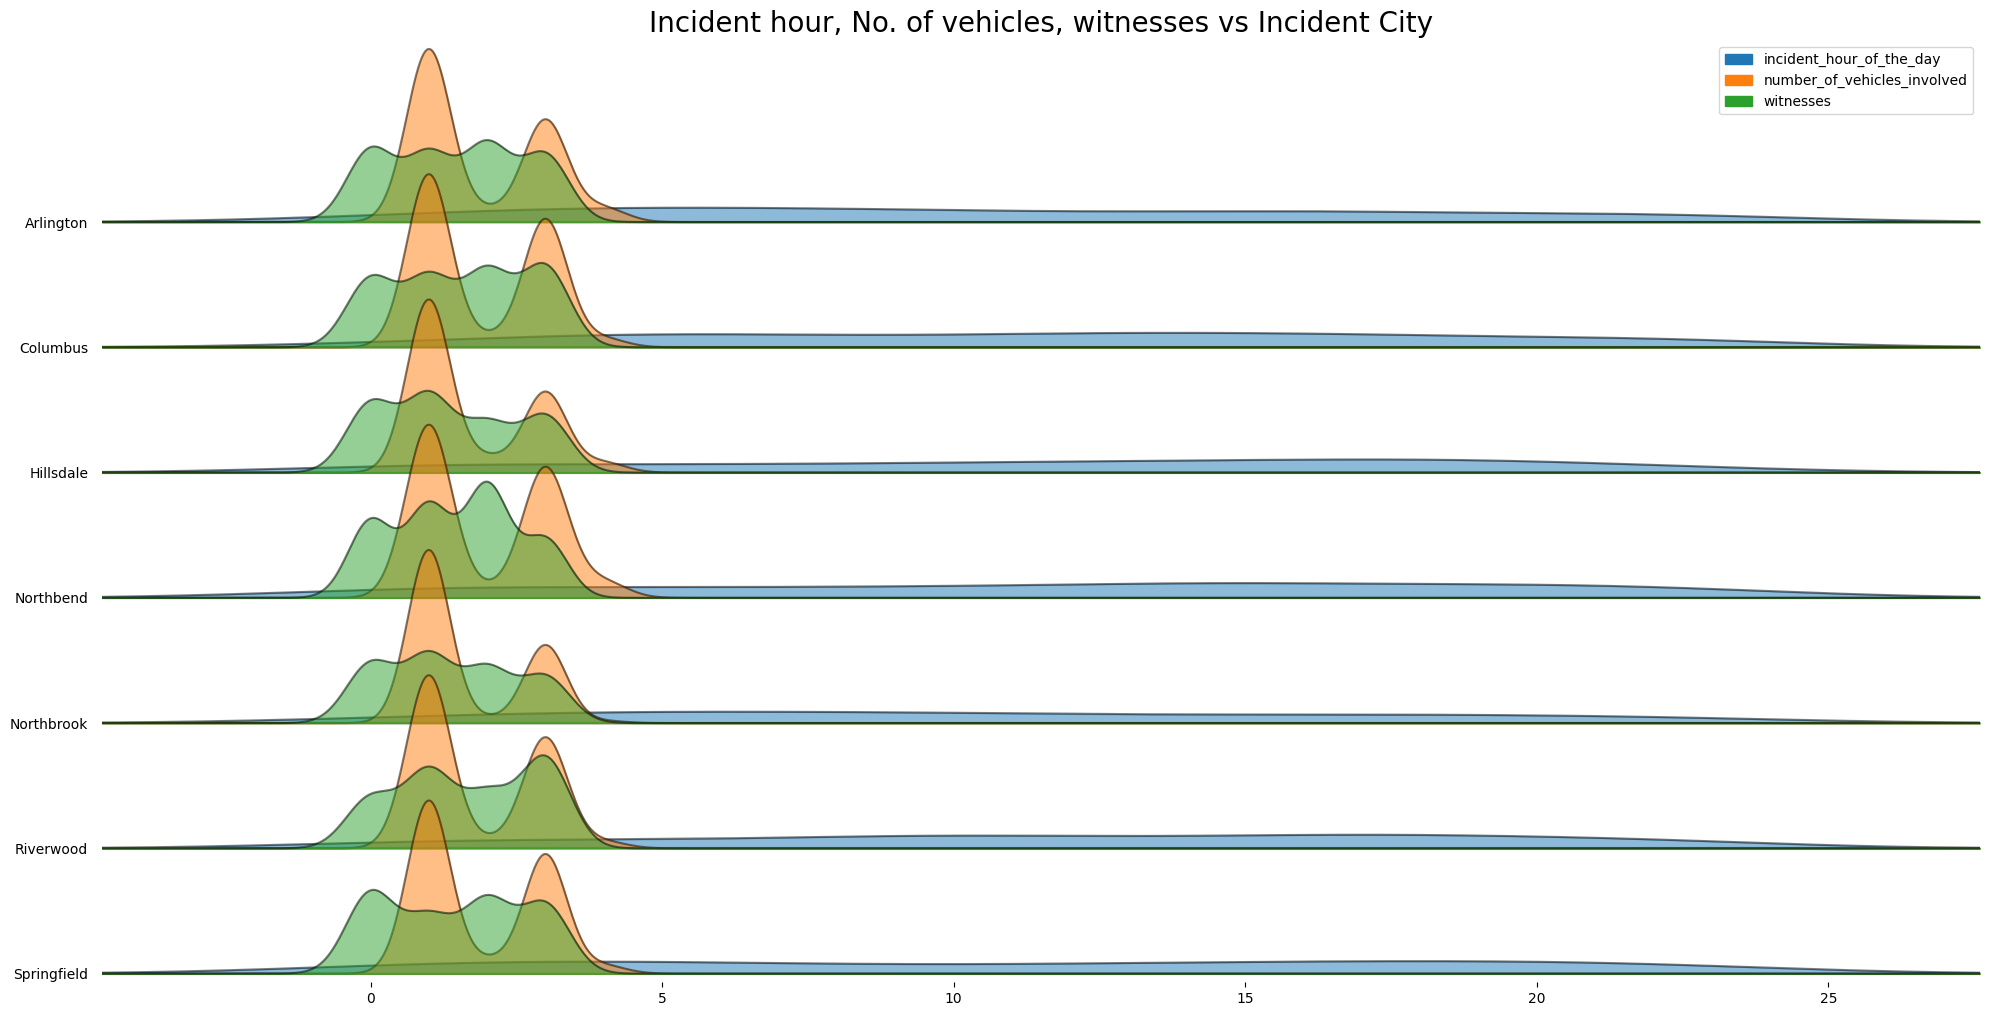

In [13]:
fig, axes = joypy.joyplot(data,
                         column = ['incident_hour_of_the_day','number_of_vehicles_involved', 'witnesses'],
                         by = 'incident_city',
                         ylim = 'own',
                         figsize = (20, 10),
                         alpha = 0.5,
                         legend = True)

plt.title('Incident hour, No. of vehicles, witnesses vs Incident City', fontsize = 20)
plt.show()

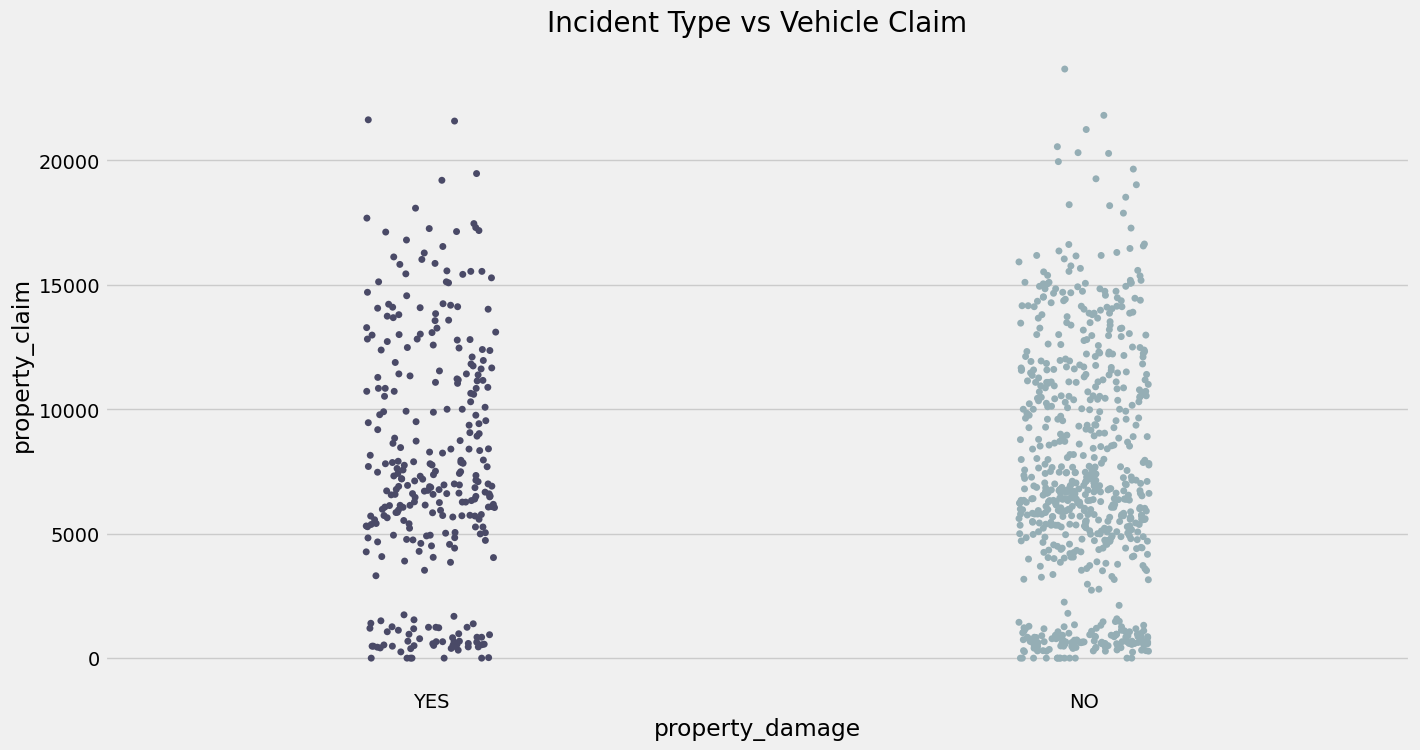

In [14]:
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (15, 8)

# Fix: Specify x and y using keyword arguments
sns.stripplot(x=data['property_damage'], y=data['property_claim'], palette = 'bone')
plt.title('Incident Type vs Vehicle Claim', fontsize = 20)
plt.show()

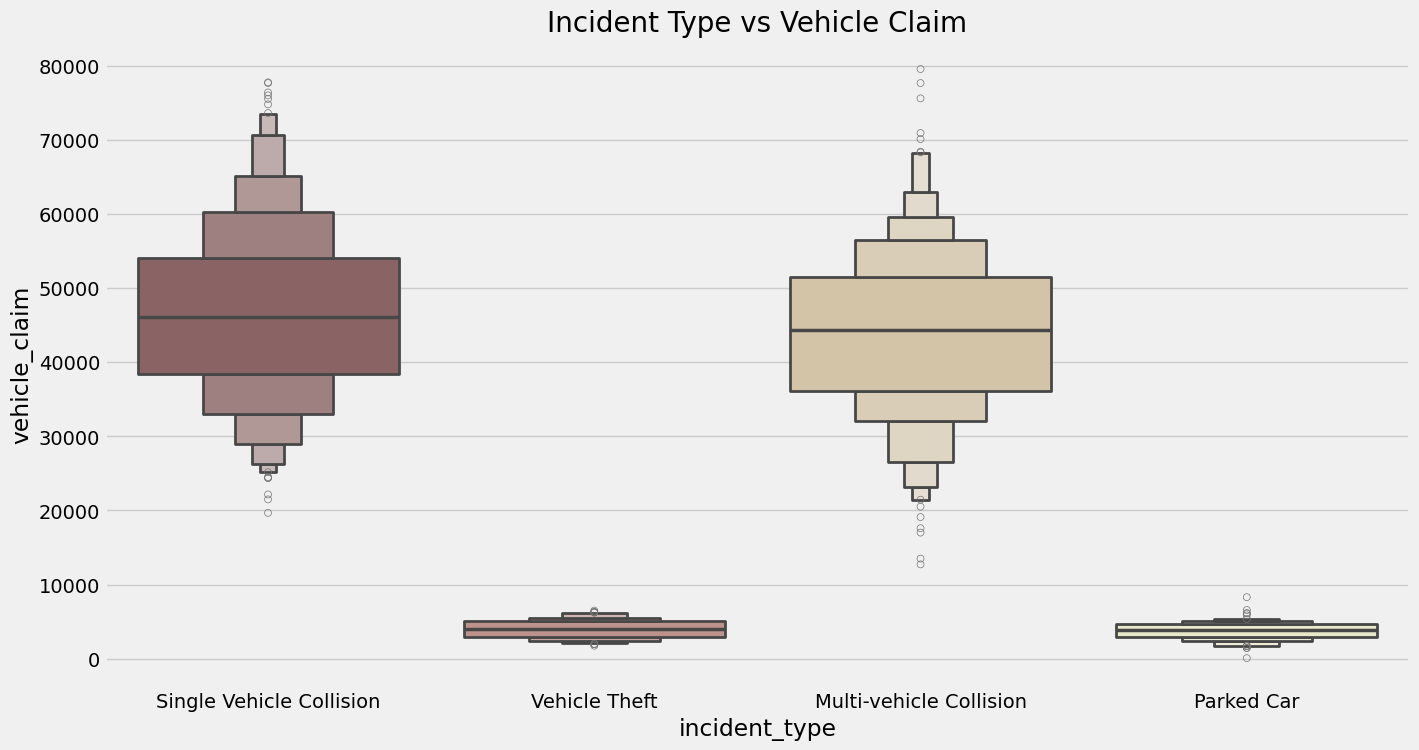

In [15]:
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (15, 8)

# Fix: Specify x and y using keyword arguments
sns.boxenplot(x='incident_type', y='vehicle_claim', data=data, palette = 'pink')
plt.title('Incident Type vs Vehicle Claim', fontsize = 20)
plt.show()

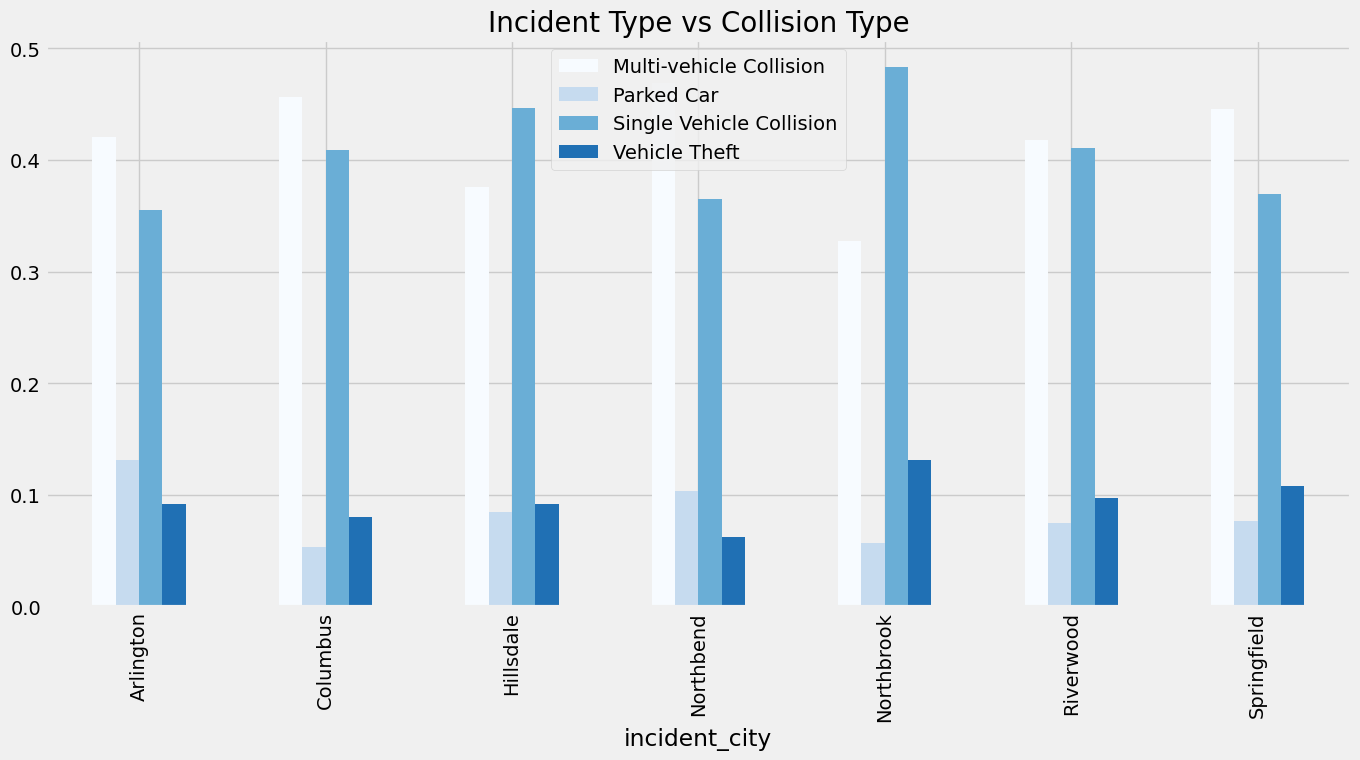

In [16]:
incident = pd.crosstab(data['incident_city'], data['incident_type'])
colors = plt.cm.Blues(np.linspace(0, 1, 5))
incident.div(incident.sum(1).astype(float), axis = 0).plot(kind = 'bar',
                                                           stacked = False,
                                                           figsize = (15, 7),
                                                           color = colors)

plt.title('Incident Type vs Collision Type', fontsize = 20)
plt.legend()
plt.show()

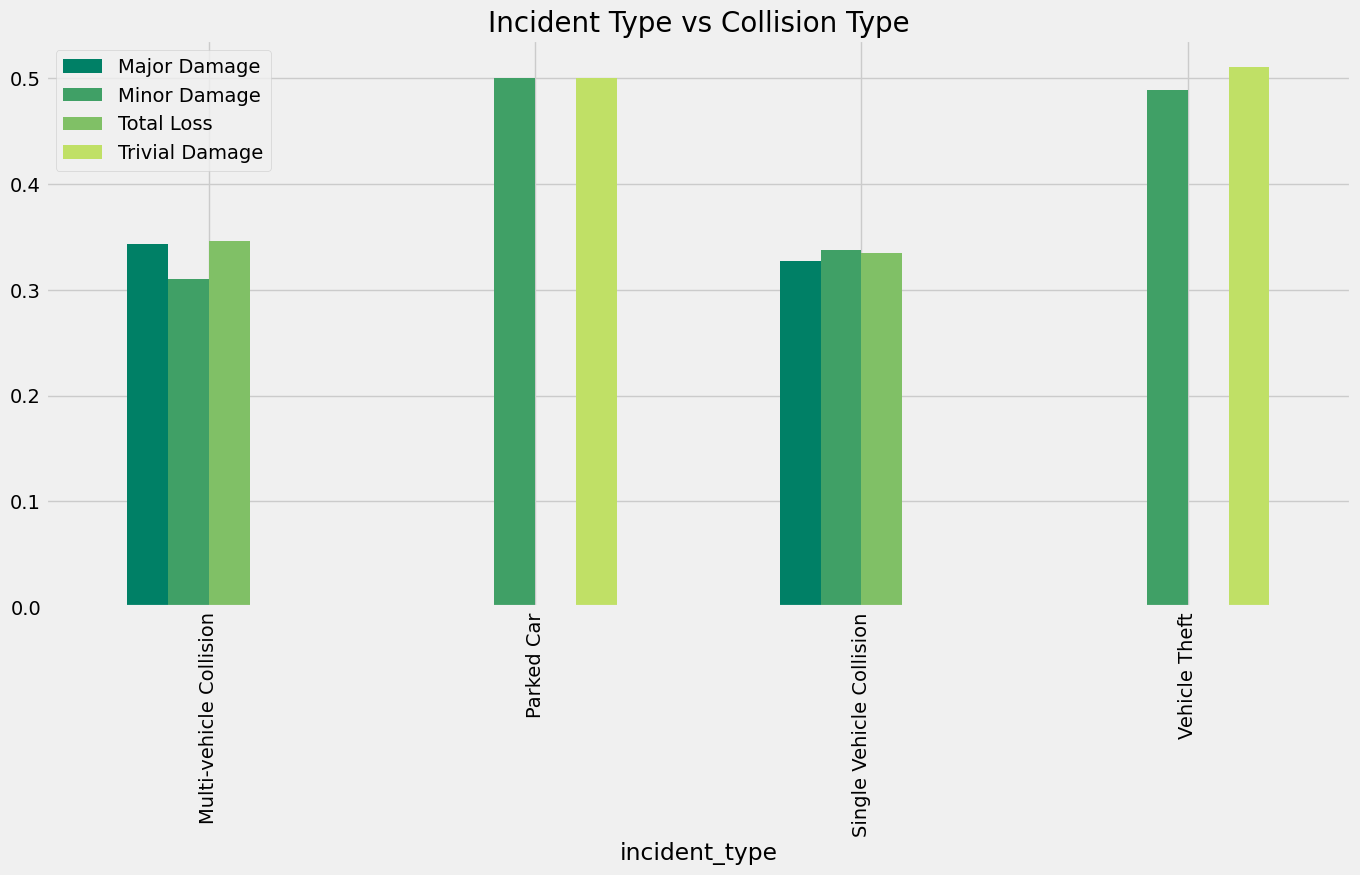

In [17]:

incident = pd.crosstab(data['incident_type'], data['incident_severity'])
colors = plt.cm.summer(np.linspace(0, 1, 5))
incident.div(incident.sum(1).astype(float), axis = 0).plot(kind = 'bar',
                                                           stacked = False,
                                                           figsize = (15, 7),
                                                           color = colors)

plt.title('Incident Type vs Collision Type', fontsize = 20)
plt.legend()
plt.show()

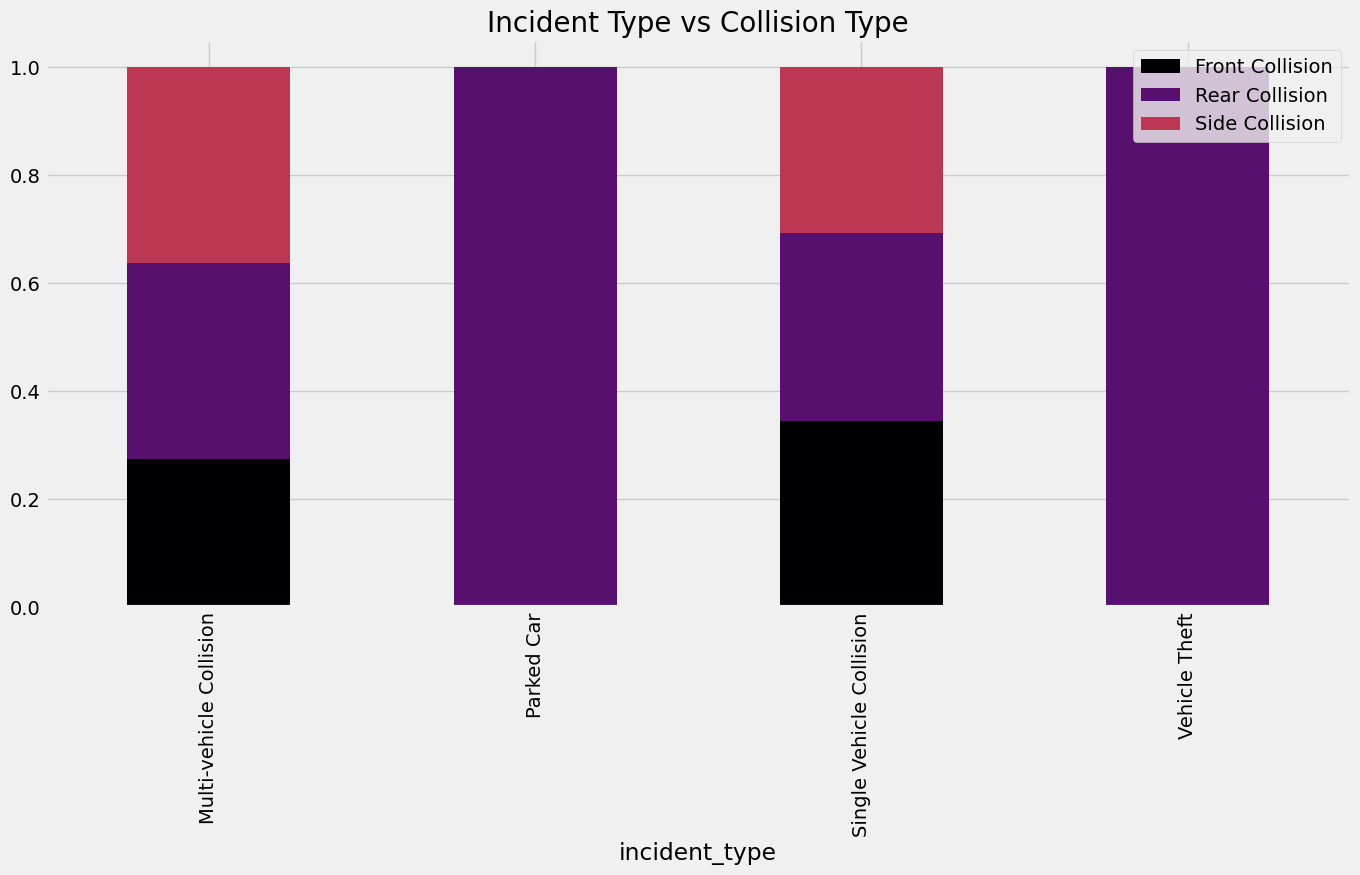

In [18]:

incident = pd.crosstab(data['incident_type'], data['collision_type'])
colors = plt.cm.inferno(np.linspace(0, 1, 5))
incident.div(incident.sum(1).astype(float), axis = 0).plot(kind = 'bar',
                                                           stacked = True,
                                                           figsize = (15, 7),
                                                           color = colors)

plt.title('Incident Type vs Collision Type', fontsize = 20)
plt.legend()
plt.show()

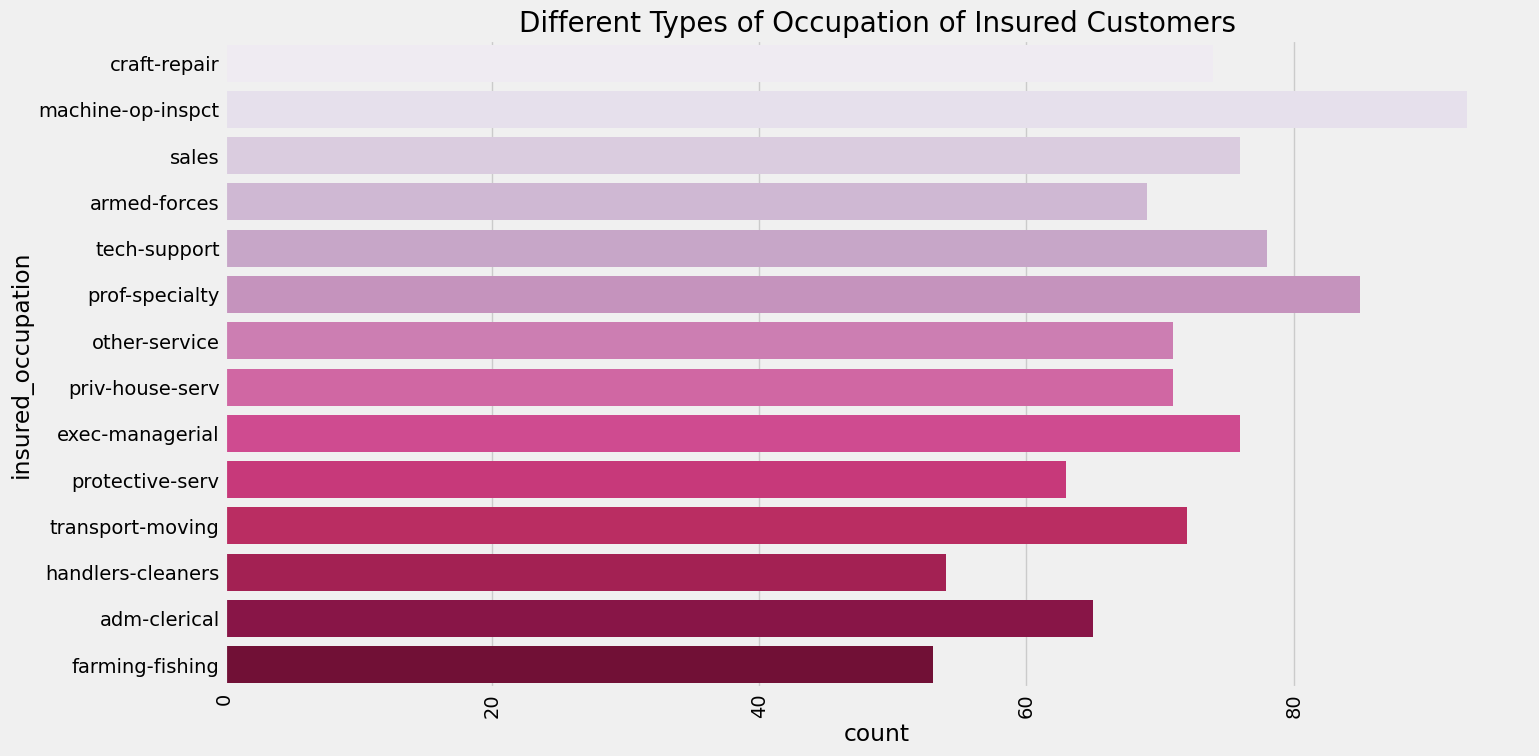

In [19]:
# let's check the insured hobbies

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (15, 8)

sns.countplot(data['insured_occupation'], palette = 'PuRd')
plt.title('Different Types of Occupation of Insured Customers', fontsize = 20)
plt.xticks(rotation = 90)
plt.show()

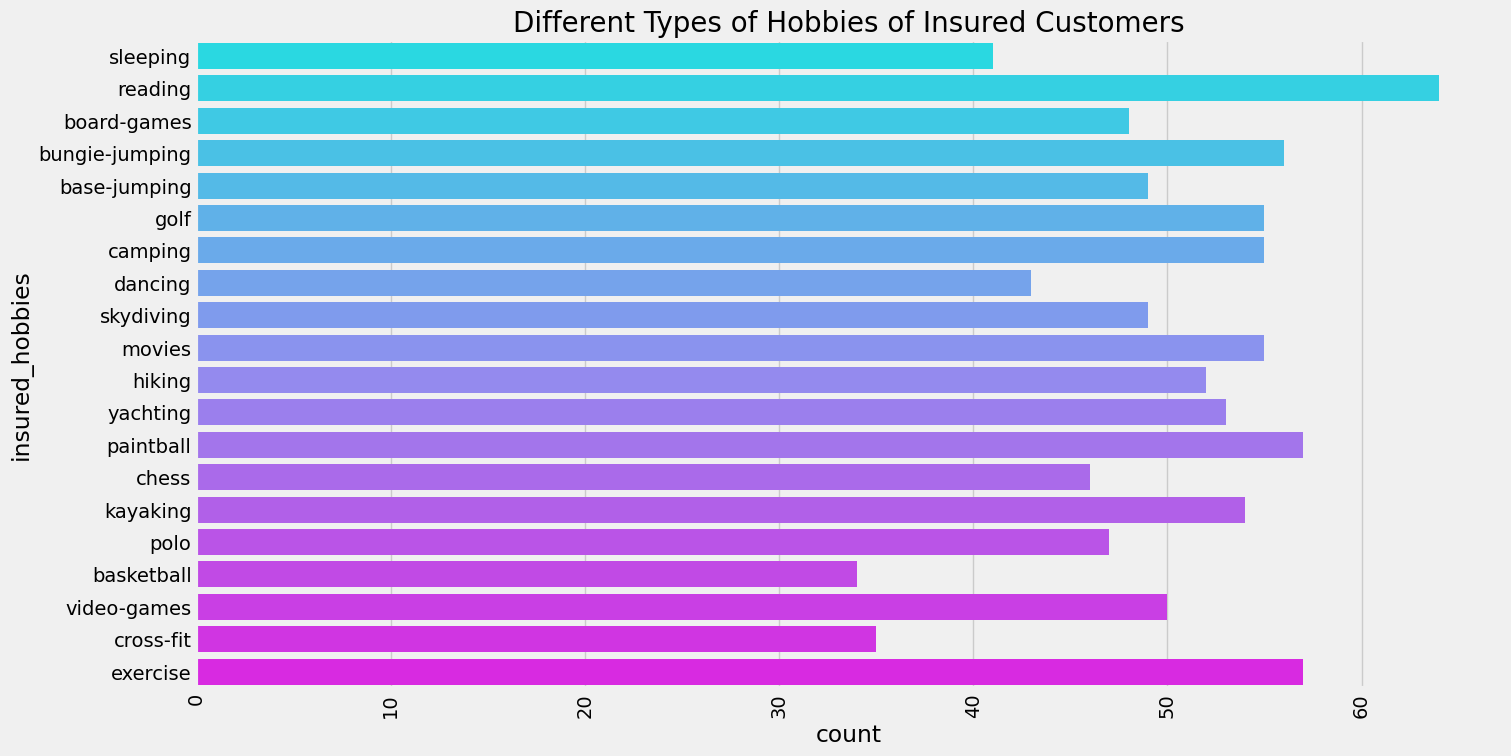

In [20]:
# let's check the insured hobbies

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (15, 8)

sns.countplot(data['insured_hobbies'], palette = 'cool')
plt.title('Different Types of Hobbies of Insured Customers', fontsize = 20)
plt.xticks(rotation = 90)
plt.show()

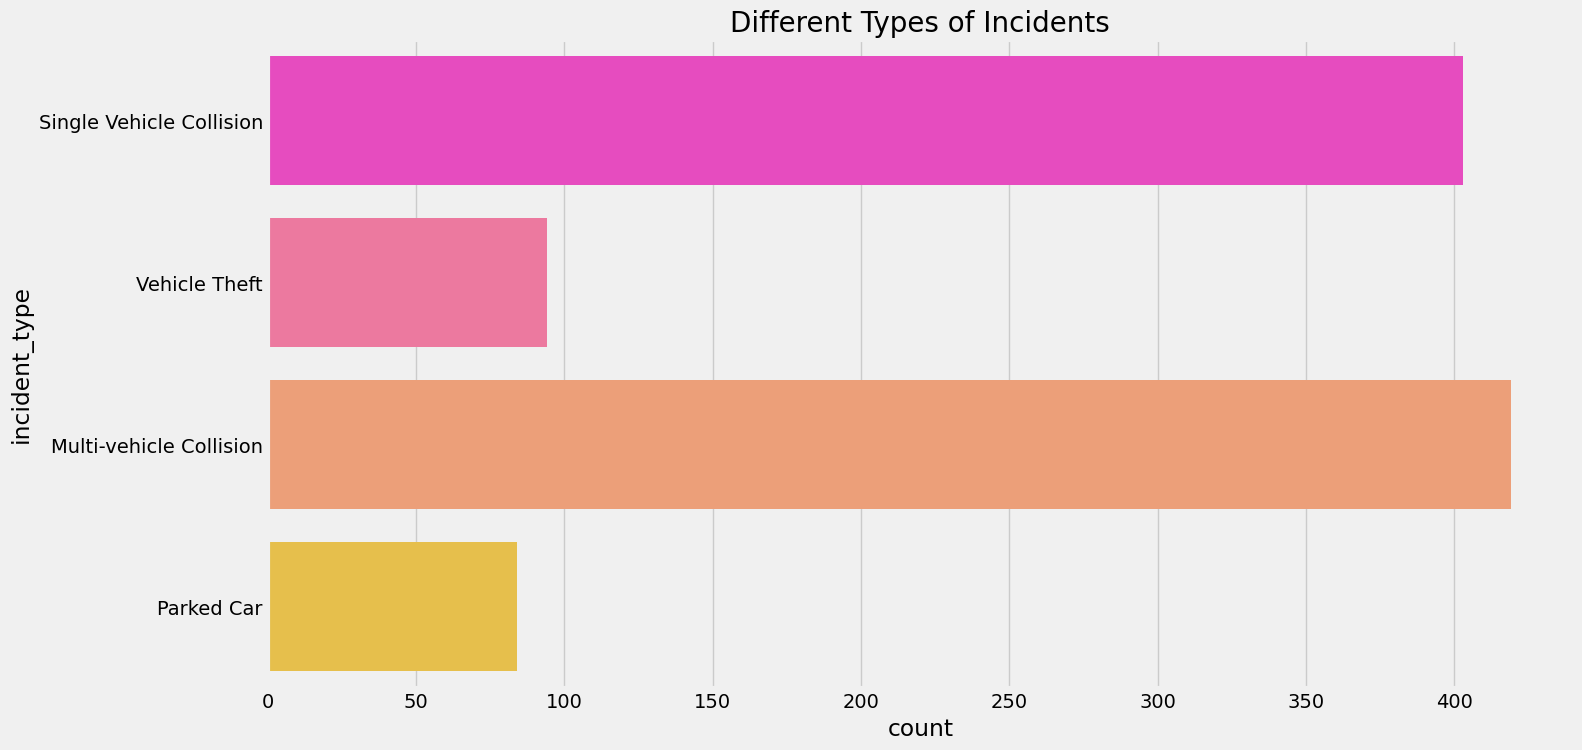

In [21]:
# let's check the incident types

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (15, 8)

sns.countplot(data['incident_type'], palette = 'spring')
plt.title('Different Types of Incidents', fontsize = 20)
plt.show()


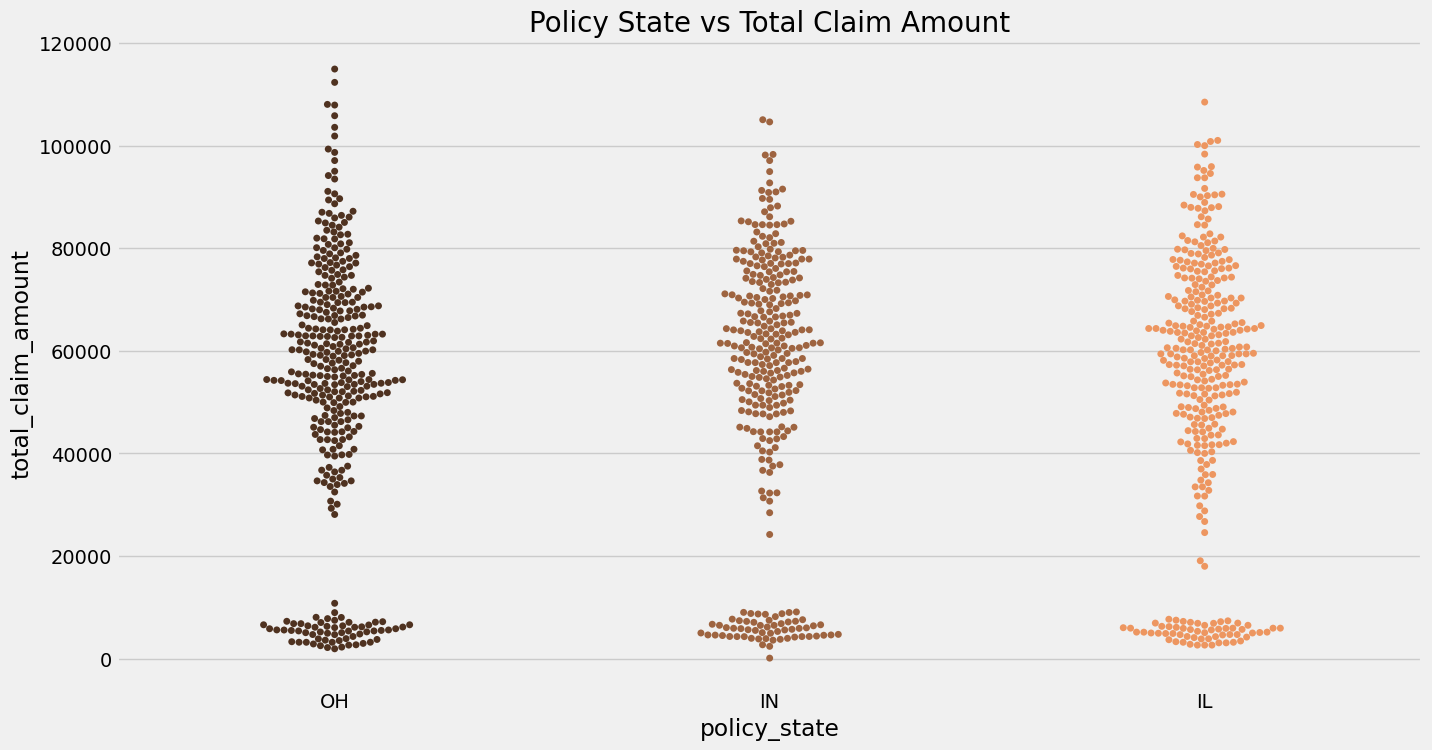

In [22]:
# swarm plot

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (15, 8)

# Pass data['policy_state'] and data['total_claim_amount'] as keyword arguments x and y
sns.swarmplot(x=data['policy_state'], y=data['total_claim_amount'], palette = 'copper')
plt.title('Policy State vs Total Claim Amount', fontsize = 20)
plt.show()

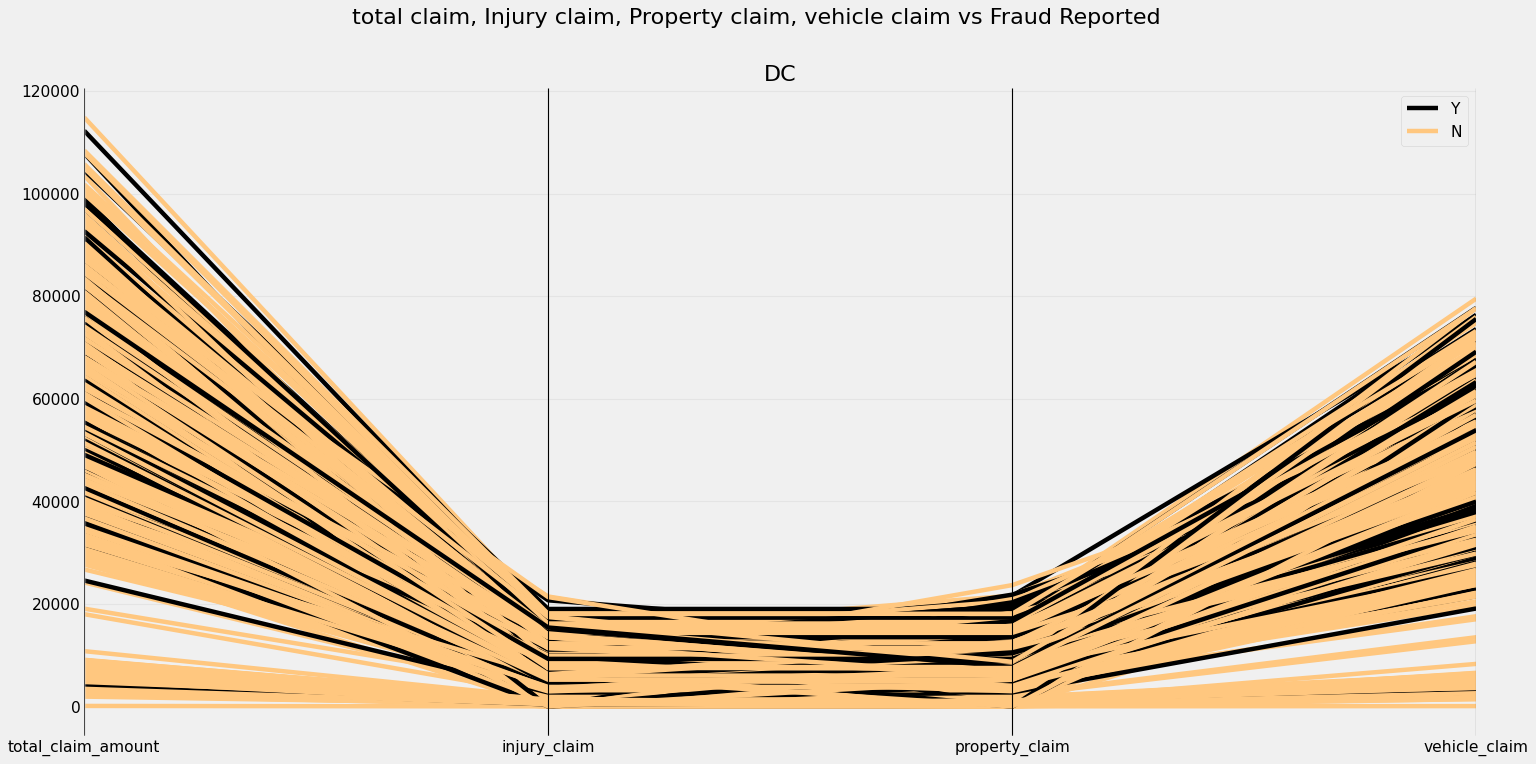

In [23]:
# Plot
plt.figure(figsize=(20, 10), dpi= 80)

parallel_coordinates(data[['total_claim_amount','injury_claim', 'property_claim','vehicle_claim','fraud_reported']],
                     'fraud_reported',  colormap = 'copper')

# Lighten borders
plt.gca().spines["top"].set_alpha(0)
plt.gca().spines["bottom"].set_alpha(.3)
plt.gca().spines["right"].set_alpha(0)
plt.gca().spines["left"].set_alpha(.3)

plt.title('DC', fontsize = 20)
plt.grid(alpha=0.3)


plt.suptitle('total claim, Injury claim, Property claim, vehicle claim vs Fraud Reported', fontsize = 20)
plt.show()

## Data Processing

In [30]:
# let's extrat days, month and year from policy bind date

data['policy_bind_date'] = pd.to_datetime(data['policy_bind_date'], errors = 'coerce')


In [31]:
# let's encode the fraud report to numerical values

data['fraud_reported'] = data['fraud_reported'].replace(('Y','N'),(0,1))

# checking the values of fraud reported
# data['fraud_reported'].value_counts()

In [32]:
# let's check the correlation of authorities_contacted with the target

data[['auto_model','fraud_reported']].groupby(['auto_model'],
                as_index = False).mean().sort_values(by = 'fraud_reported', ascending = False)

,auto_model,fraud_reported
0,3 Series,0.944444
31,RSX,0.916667
25,Malibu,0.900000
36,Wrangler,0.880952
29,Pathfinder,0.870968
35,Ultima,0.869565
9,Camry,0.857143
11,Corolla,0.850000
8,CRV,0.850000
21,Legacy,0.843750


In [33]:
# let's perform target encoding for auto make

data['auto_make'] = data['auto_make'].replace(('3 Series','RSX','Malibu','Wrangler','Pathfinder','Ultima','Camry',
                'Corolla','CRV','Legacy','Neon','95','TL','93','MDX','Accord','Grand Cherokee','Escape','E4000',
            'A3','Highlander','Passat','92x','Jetta','Fusion','Forrestor','Maxima','Impreza','X5','RAM','M5','A5',
                'Civic','F150','Tahaoe','C300','ML350','Silverado','X6'),
                (0.95,0.91, 0.90,0.88,0.87,0.86,0.855,0.85,0.85,0.84,0.83,0.81,0.80,0.80,0.78,0.77,0.76,0.75,0.74,
                 0.73,0.72,0.72,0.71,0.71,0.71,0.71,0.70,0.70,0.69,0.67,0.66,0.65,0.64,0.63,0.62,0.61,0.60,0.59,0.56))

# let's check the values
# data['auto_make'].value_counts()

In [34]:
# let's check the correlation auto make with the target

data[['auto_make','fraud_reported']].groupby(['auto_make'],
                as_index = False).mean().sort_values(by = 'fraud_reported', ascending = False)

,auto_make,fraud_reported
7,Jeep,0.835821
9,Nissan,0.820513
12,Toyota,0.814286
0,Accura,0.808824
10,Saab,0.775000
11,Suburu,0.762500
4,Dodge,0.750000
6,Honda,0.745455
3,Chevrolet,0.723684
2,BMW,0.722222


In [35]:
# let's perform target encoding for auto make

data['auto_make'] = data['auto_make'].replace(('Jeep','Nissan','Toyota','Accura','Saab','Suburu',
                                'Dodge','Honda','Chevrolet','BMW','Volkswagen','Audi','Ford','Mercedes'),
                                              (0.84,0.82,0.81,0.80,0.77,0.76,0.75,0.74,0.73,0.72,0.71,0.69,0.69,0.66))

# let's check the values
# data['auto_make'].value_counts()

In [36]:
# let's check the correlation of authorities_contacted with the target

data[['police_report_available','fraud_reported']].groupby(['police_report_available'],
                as_index = False).mean().sort_values(by = 'fraud_reported', ascending = False)

,police_report_available,fraud_reported
1,YES,0.770701
0,NO,0.744898


In [37]:
# let's perform target encoding for property damage

data['police_report_available'] = data['police_report_available'].replace(('NO','YES'),(0.77,0.74))

# let's check the values
# data['police_report_available'].value_counts()

In [38]:
# let's check the correlation of authorities_contacted with the target

data[['property_damage','fraud_reported']].groupby(['property_damage'],
                as_index = False).mean().sort_values(by = 'fraud_reported', ascending = False)

,property_damage,fraud_reported
0,NO,0.757880
1,YES,0.741722


In [39]:
# let's perform target encoding for property damage

data['property_damage'] = data['property_damage'].replace(('NO','YES'),(0.76,0.74))

# let's check the values
# data['property_damage'].value_counts()

In [40]:
# let's check the correlation of authorities_contacted with the target

data[['incident_city','fraud_reported']].groupby(['incident_city'],
                as_index = False).mean().sort_values(by = 'fraud_reported', ascending = False)

,incident_city,fraud_reported
4,Northbrook,0.778689
5,Riverwood,0.776119
3,Northbend,0.765517
6,Springfield,0.757962
2,Hillsdale,0.751773
1,Columbus,0.738255
0,Arlington,0.710526


In [41]:
# let's do target encoding for incident city

data['incident_city'] = data['incident_city'].replace(('Northbrook','Riverwood','Northbend','Springfield',
                                    'Hillsdale','Columbus','Arlington'),(0.78,0.77,0.76,0.75,0.74,0.73,0.71))

# let's check the values
# data['incident_city'].value_counts()

In [42]:
# let's check the correlation of authorities_contacted with the target

data[['incident_state','fraud_reported']].groupby(['incident_state'],
                as_index = False).mean().sort_values(by = 'fraud_reported', ascending = False)

,incident_state,fraud_reported
6,WV,0.820276
1,NY,0.778626
5,VA,0.772727
3,PA,0.733333
4,SC,0.705645
0,NC,0.690909
2,OH,0.565217


In [43]:
# let's perform target encoding for incident state

data['incident_state'] = data['incident_state'].replace(('WV','NY','VA','PA','SC','NC','OH'),
                                                        (0.82,0.77,0.76,0.73,0.70,0.69,0.56))

# checking the values
# data['incident_state'].value_counts()

In [44]:
# let's check the correlation of authorities_contacted with the target

data[['authorities_contacted','fraud_reported']].groupby(['authorities_contacted'],
                as_index = False).mean().sort_values(by = 'fraud_reported', ascending = False)

,authorities_contacted,fraud_reported
3,Police,0.791096
1,Fire,0.730942
0,Ambulance,0.709184
2,Other,0.681818


In [45]:
# let's perform target encoding for authorities contacted

data['authorities_contacted'] = data['authorities_contacted'].replace(('None','Police','Fire','Ambulance','Other'),
                                                                      (0.94,0.79,0.73,0.70,0.68))

# let's check the values
#data['authorities'].value_counts()

In [46]:
# let's check the correlation of incident_severity with the target

data[['incident_severity','fraud_reported']].groupby(['incident_severity'],
                as_index = False).mean().sort_values(by = 'fraud_reported', ascending = False)

,incident_severity,fraud_reported
3,Trivial Damage,0.933333
1,Minor Damage,0.892655
2,Total Loss,0.871429
0,Major Damage,0.394928


In [47]:
# let's perform target encoding for incident severity

data['incident_severity'] = data['incident_severity'].replace(('Trivial Damage','Minor Damage','Total Loss',
                                                              'Major Damage'),(0.94,0.89,0.87,0.39))

# let's check the values
# data['incident_severity'].value_counts()

In [48]:
# let's check the correlation of collision_type with the target

data[['collision_type','fraud_reported']].groupby(['collision_type'],
                as_index = False).mean().sort_values(by = 'fraud_reported', ascending = False)

,collision_type,fraud_reported
1,Rear Collision,0.772340
2,Side Collision,0.746377
0,Front Collision,0.724409


In [49]:
# let's perform target encoding for collision type

data['collision_type'] = data['collision_type'].replace(('Rear Collision', 'Side Collision', 'Front Collision'),
                                                        (0.78,0.74,0.72))

# let's check the values of collision type
# data['collision_type'].value_counts()

In [50]:
# let's check the correlation of incident_type with the target

data[['incident_type','fraud_reported']].groupby(['incident_type'],
                as_index = False).mean().sort_values(by = 'fraud_reported', ascending = False)

,incident_type,fraud_reported
3,Vehicle Theft,0.914894
1,Parked Car,0.904762
0,Multi-vehicle Collision,0.727924
2,Single Vehicle Collision,0.709677


In [51]:
# let's perform target encoing for incident type

data['incident_type'] = data['incident_type'].replace(('Vehicle Theft','Parked Car','Multi-vehicle Collision',
                                'Single Vehicle Collision'),(0.91, 0.90, 0.72,0.70))

# let's check the values
#data['incident_type'].value_counts()

In [52]:
data['incident_date'] = pd.to_datetime(data['incident_date'], errors = 'coerce')

# extracting days and month from date
data['incident_month'] = data['incident_date'].dt.month
data['incident_day'] = data['incident_date'].dt.day


In [53]:
# let's know the relation between insured_relationship and fraud reported

data[['insured_relationship','fraud_reported']].groupby(['insured_relationship'],
                as_index = False).mean().sort_values(by = 'fraud_reported', ascending = False)

,insured_relationship,fraud_reported
0,husband,0.794118
3,own-child,0.786885
4,unmarried,0.758865
1,not-in-family,0.741379
5,wife,0.729032
2,other-relative,0.706215


In [54]:
# let's do target encoding for insured relationship

data['insured_relationship'] = data['insured_relationship'].replace(('husband','own-child','unmarried',
                                        'not-in-family','wife','other-relative'),(0.79,0.78,0.75,0.74,0.72,0.70))

#data['insured-relationship'].value_counts()

In [55]:
# let's know the relation between insured_hobbies and fraud reported

data[['insured_hobbies','fraud_reported']].groupby(['insured_hobbies'],
                as_index = False).mean().sort_values(by = 'fraud_reported', ascending = False)

,insured_hobbies,fraud_reported
4,camping,0.909091
11,kayaking,0.907407
9,golf,0.890909
7,dancing,0.883721
3,bungie-jumping,0.839286
12,movies,0.836364
1,basketball,0.823529
8,exercise,0.807018
17,sleeping,0.804878
18,video-games,0.800000


In [56]:
# let's perform target encoding for insured_hobbies

data['insured_hobbies'] = data['insured_hobbies'].replace(('camping', 'kayaking', 'golf','dancing',
        'bungie-jumping','movies', 'basketball','exercise','sleeping','video-games','skydiving','paintball',
            'hiking','base-jumping','reading','polo','board-games','yachting', 'cross-fit','chess'),(0.91, 0.90,
                0.89, 0.88,0.84,0.83,0.82,0.81,0.805,0.80,0.78,0.77,0.76,0.73,0.73,0.72,0.70,0.69,0.25,0.17))

#data['insured_hobbies'].value_counts()

In [57]:
# let's know the relation between insured_occupation and fraud reported

data[['insured_occupation','fraud_reported']].groupby(['insured_occupation'],
                as_index = False).mean().sort_values(by = 'fraud_reported', ascending = False)

,insured_occupation,fraud_reported
7,other-service,0.830986
8,priv-house-serv,0.830986
0,adm-clerical,0.830769
5,handlers-cleaners,0.796296
9,prof-specialty,0.788235
10,protective-serv,0.777778
6,machine-op-inspct,0.763441
1,armed-forces,0.753623
11,sales,0.723684
12,tech-support,0.717949


In [58]:
# let's perform target encoding for insured_occupation

data['insured_occupation'] = data['insured_occupation'].replace(('other-service','priv-house-serv',
                        'adm-clerical','handlers-cleaners','prof-specialty','protective-serv',
                'machine-op-inspct','armed-forces','sales','tech-support','transport-moving','craft-repair',
                    'farming-fishing','exec-managerial'),(0.84, 0.84,0.83, 0.79,0.78,0.77,0.76,0.75,0.72,0.71,
                                                          0.705,0.70,0.69,0.63))
# data['insured_occupation'].value_counts()

In [59]:
# let's know the relation of insured_education_level with faud_reported

data[['insured_education_level','fraud_reported']].groupby(['insured_education_level'],
                as_index = False).mean().sort_values(by = 'fraud_reported', ascending = False)

,insured_education_level,fraud_reported
5,Masters,0.776224
2,High School,0.775000
0,Associate,0.765517
3,JD,0.739130
1,College,0.737705
4,MD,0.736111
6,PhD,0.736000


In [60]:
# let's perform target encoding

data['insured_education_level'] = data['insured_education_level'].replace(('Masters', 'High School','Associate',
                                        'JD','College', 'MD','PhD'),(0.78,0.77,0.76,0.74,0.73,0.72,0.71))
#data['insured_education_level'].value_counts()

In [61]:
# lets know the relation of insured sex and fraud reported

data[['insured_sex','fraud_reported']].groupby(['insured_sex'], as_index = False).mean().sort_values(
    by = 'fraud_reported', ascending = False)

,insured_sex,fraud_reported
0,FEMALE,0.765363
1,MALE,0.738661


In [62]:
# target encoding for sex

data['insured_sex'] = data['insured_sex'].replace(('FEMALE','MALE'),(0.76,0.73))
#data['insured_sex'].value_counts()

In [63]:
# csl - combined single limit

'''CSL is a single number that describes the predetermined limit for the combined total of the Bodily Injury
Liability coverage and Property Damage Liability coverage per occurrence or accident.'''

# lets know the relation of policy state and fraud reported

data[['policy_csl','fraud_reported']].groupby(['policy_csl'], as_index = False).mean().sort_values(
    by = 'fraud_reported', ascending = False)

,policy_csl,fraud_reported
2,500/1000,0.783333
0,100/300,0.742120
1,250/500,0.737892


In [64]:
# target encoding for policy_csl

data['policy_csl'] = data['policy_csl'].replace(('500/1000','100/300','250/500'),(0.78,0.74,0.73))

# check the values
# data['policy_csl'].value_counts()

In [65]:

# lets know the relation of policy state and fraud reported

data[['policy_state','fraud_reported']].groupby(['policy_state'], as_index = False).mean().sort_values(
    by = 'fraud_reported', ascending = False)


,policy_state,fraud_reported
0,IL,0.772189
1,IN,0.745161
2,OH,0.741477


In [66]:
# target encoding for policy_csl

data['policy_state'] = data['policy_state'].replace(('IL','IN','OH'),(0.77,0.745,0.74))

# check the values
# data['policy_state'].value_counts()

In [67]:
# let's delete unnecassary columns

data = data.drop(['policy_number','policy_bind_date', 'incident_date','incident_location','auto_model'], axis = 1)

# let's check the columns after deleting the columns
data.columns

Index(['months_as_customer', 'age', 'policy_state', 'policy_csl',
       'policy_deductable', 'policy_annual_premium', 'umbrella_limit',
       'insured_zip', 'insured_sex', 'insured_education_level',
       'insured_occupation', 'insured_hobbies', 'insured_relationship',
       'capital-gains', 'capital-loss', 'incident_type', 'collision_type',
       'incident_severity', 'authorities_contacted', 'incident_state',
       'incident_city', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_year', 'fraud_reported', 'incident_month', 'incident_day'],
      dtype='object')

In [68]:
# let's split the data into dependent and independent sets

x = data.drop(['fraud_reported'], axis = 1)
y = data['fraud_reported']

print("Shape of x :", x.shape)
print("Shape of y :", y.shape)

Shape of x : (1000, 35)
Shape of y : (1000,)


In [69]:
# let's split the dataset into train and test sets

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

print("Shape of x_train :", x_train.shape)
print("Shape of x_test :", x_test.shape)
print("Shape of y_train :", y_train.shape)
print("Shape of y_test :", y_test.shape)

Shape of x_train : (800, 35)
Shape of x_test : (200, 35)
Shape of y_train : (800,)
Shape of y_test : (200,)


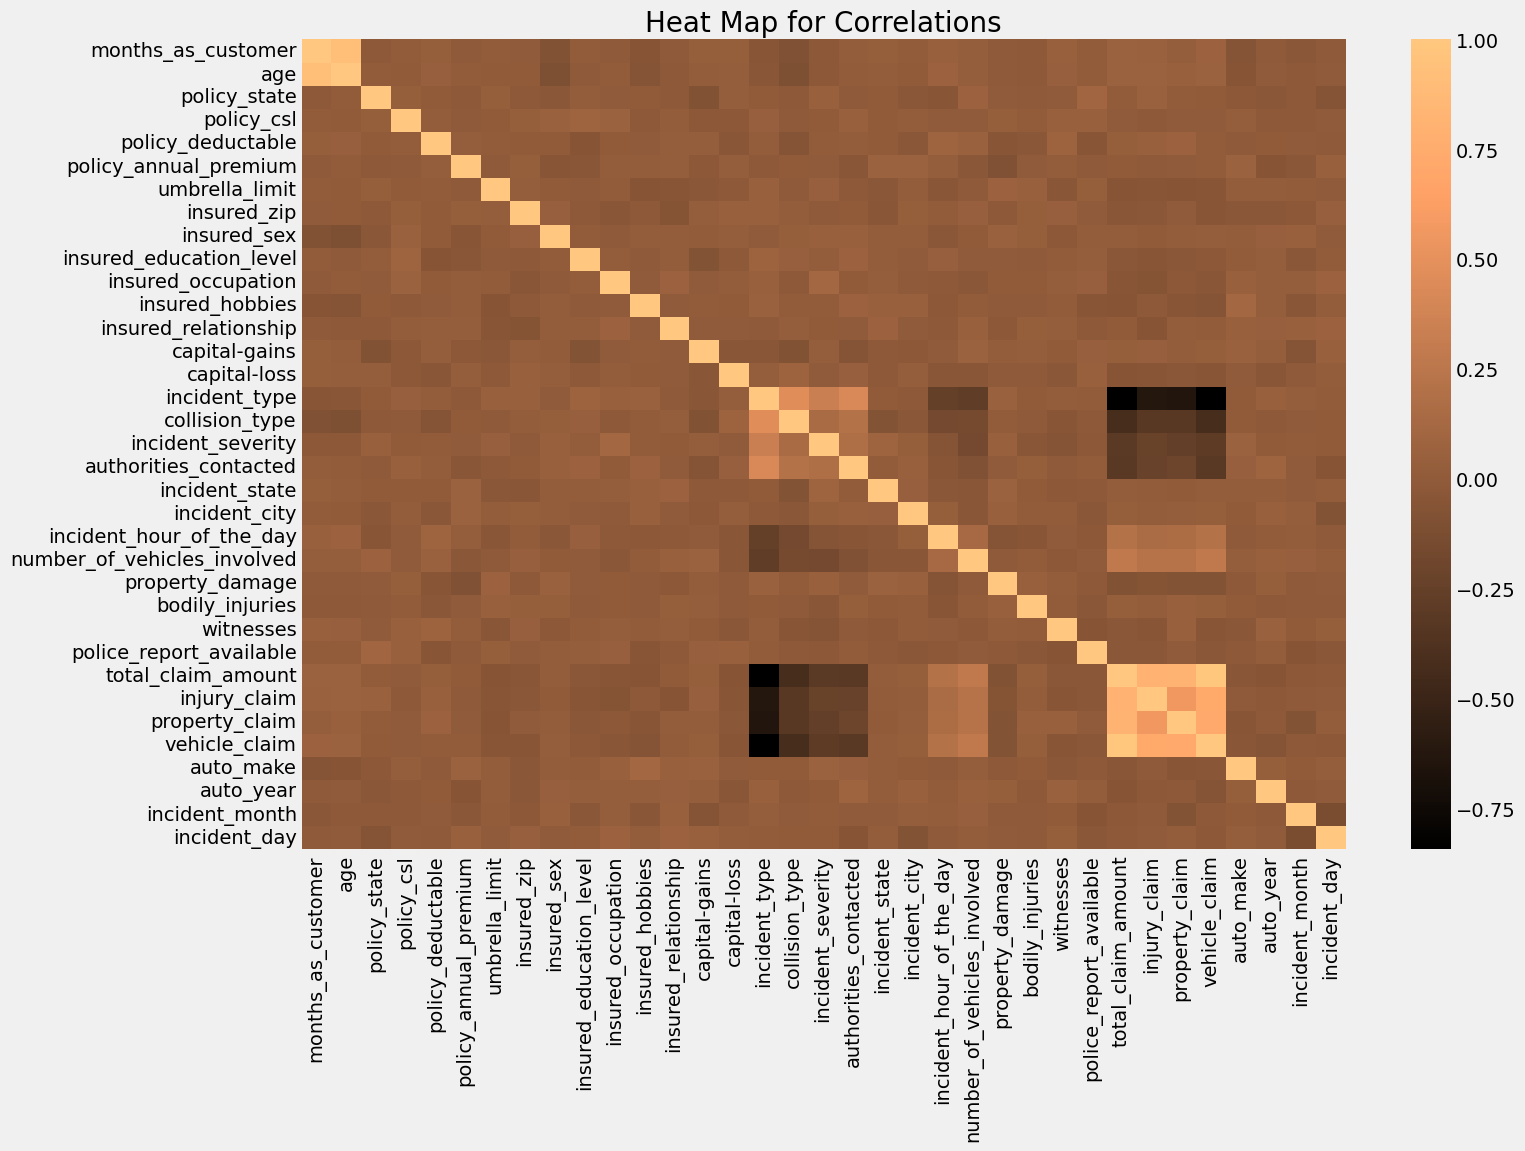

In [70]:
plt.rcParams['figure.figsize'] = (15, 10)
sns.heatmap(x_train.corr(), cmap = 'copper')
plt.title('Heat Map for Correlations', fontsize = 20)
plt.show()

## Modelling with Ensemble of Samplers

**Random Forest Classifier**

Training Accuracy:  0.9025
Testing Accuarcy:  0.835
              precision    recall  f1-score   support

           0       0.67      0.82      0.74        57
           1       0.92      0.84      0.88       143

    accuracy                           0.83       200
   macro avg       0.80      0.83      0.81       200
weighted avg       0.85      0.83      0.84       200



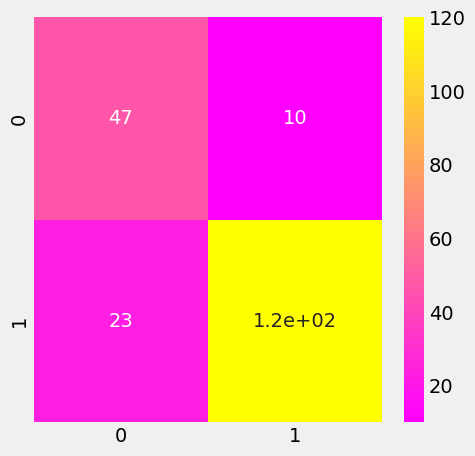

In [71]:
# Random Forest Classifier

from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


model = BalancedRandomForestClassifier(n_estimators = 100, random_state = 0)

model.fit(x_train, y_train)
y_pred_rf = model.predict(x_test)

print("Training Accuracy: ", model.score(x_train, y_train))
print('Testing Accuarcy: ', model.score(x_test, y_test))

# making a classification report
cr = classification_report(y_test,  y_pred_rf)
print(cr)

# making a confusion matrix
plt.rcParams['figure.figsize'] = (5, 5)
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot = True, cmap = 'spring')
plt.show()

**Easy Ensemble Classifier**

Training Accuracy:  0.86375
Testing Accuarcy:  0.85
              precision    recall  f1-score   support

           0       0.71      0.81      0.75        57
           1       0.92      0.87      0.89       143

    accuracy                           0.85       200
   macro avg       0.81      0.84      0.82       200
weighted avg       0.86      0.85      0.85       200



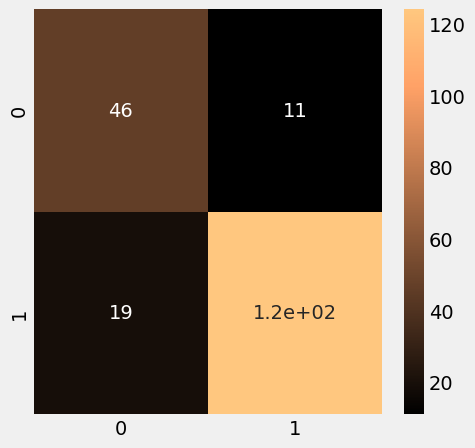

In [72]:
#!pip install scikit-learn

import pandas as pd
from sklearn.impute import SimpleImputer
from imblearn.ensemble import EasyEnsembleClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


# Create a SimpleImputer to replace NaN with the mean of the column
imputer = SimpleImputer(strategy='mean')  # You can change the strategy if needed

# Fit the imputer on your training data and transform both train and test data
x_train_imputed = imputer.fit_transform(x_train)
x_test_imputed = imputer.transform(x_test)

# Now use the imputed data for training your model
model1 = EasyEnsembleClassifier(n_estimators = 100, random_state = 0)
model1.fit(x_train_imputed, y_train)  # Use imputed training data
y_pred_ef = model1.predict(x_test_imputed) # Use imputed test data

print("Training Accuracy: ", model1.score(x_train_imputed, y_train)) # Use imputed training data
print('Testing Accuarcy: ', model1.score(x_test_imputed, y_test)) # Use imputed test data

# making a classification report
cr = classification_report(y_test,  y_pred_ef)
print(cr)

# making a confusion matrix
cm = confusion_matrix(y_test, y_pred_ef)
sns.heatmap(cm, annot = True, cmap = 'copper')
plt.show()

**Bagging Classifier**

Training Accuracy:  0.94125
Testing Accuarcy:  0.845
              precision    recall  f1-score   support

           0       0.70      0.79      0.74        57
           1       0.91      0.87      0.89       143

    accuracy                           0.84       200
   macro avg       0.81      0.83      0.82       200
weighted avg       0.85      0.84      0.85       200



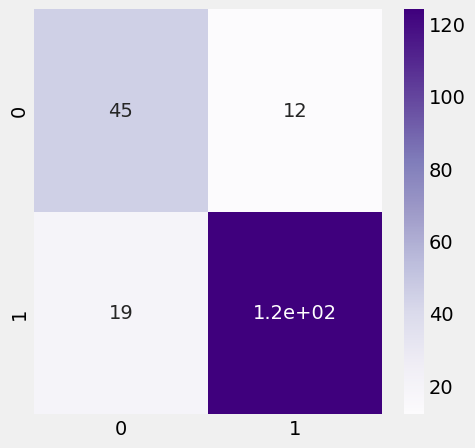

In [73]:
# Random Forest with Bagging Classifier

from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier


# Instead of 'base_estimator', use 'estimator'
model2 = BalancedBaggingClassifier(estimator = RandomForestClassifier(), # Changed 'base_estimator' to 'estimator'
                                 sampling_strategy = 'auto',
                                 replacement = False,
                                 random_state = 0)

model2.fit(x_train, y_train)
y_pred_bc = model2.predict(x_test)

print("Training Accuracy: ", model2.score(x_train, y_train))
print('Testing Accuarcy: ', model2.score(x_test, y_test))

# making a classification report
cr = classification_report(y_test,  y_pred_bc)
print(cr)

# making a confusion matrix
cm = confusion_matrix(y_test, y_pred_bc)
sns.heatmap(cm, annot = True, cmap = 'Purples')
plt.show()

**Boosting the Predictions of above Models**

Accuracy: 0.84
              precision    recall  f1-score   support

           0       0.68      0.84      0.75        57
           1       0.93      0.84      0.88       143

    accuracy                           0.84       200
   macro avg       0.80      0.84      0.82       200
weighted avg       0.86      0.84      0.84       200



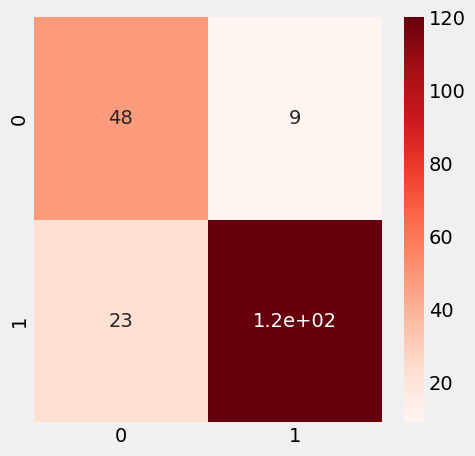

In [82]:
from sklearn.metrics import accuracy_score
# boosting

y_pred = y_pred_rf*0.5 + y_pred_ef*0.2 + y_pred_bc*0.3

y_pred[y_pred > 0.5] = 1
y_pred[y_pred <= 0.5] = 0
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
# making a classification report
cr = classification_report(y_test,  y_pred)
print(cr)

# making a confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot = True, cmap = 'Reds')
plt.show()



**Voting Classifier**

Training Accuracy:  0.90125
Testing Accuarcy:  0.865
Accuracy: 0.865
              precision    recall  f1-score   support

           0       0.73      0.84      0.78        57
           1       0.93      0.87      0.90       143

    accuracy                           0.86       200
   macro avg       0.83      0.86      0.84       200
weighted avg       0.87      0.86      0.87       200



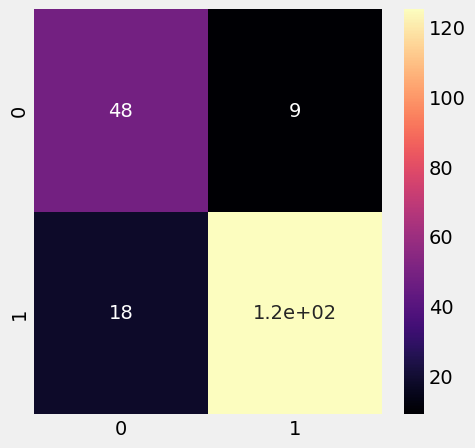

In [85]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import VotingClassifier
from imblearn.ensemble import BalancedRandomForestClassifier, BalancedBaggingClassifier, EasyEnsembleClassifier

# Create an imputer to replace NaN values with the mean of each column
imputer = SimpleImputer(strategy='mean')

# Fit the imputer to your training data and transform both training and testing data
x_train_imputed = imputer.fit_transform(x_train)
x_test_imputed = imputer.transform(x_test)

# Convert the imputed data back to DataFrame if necessary
x_train_imputed = pd.DataFrame(x_train_imputed, columns=x_train.columns)
x_test_imputed = pd.DataFrame(x_test_imputed, columns=x_test.columns)

vote_est = [
    ('brf', BalancedRandomForestClassifier()),
    ('bc', BalancedBaggingClassifier()),
    ('eec', EasyEnsembleClassifier())
]

voting = VotingClassifier(estimators=vote_est, voting='soft')

# Fit the VotingClassifier using the imputed training data
voting.fit(x_train_imputed, y_train)

y_pred = voting.predict(x_test_imputed).astype(int)

print("Training Accuracy: ", voting.score(x_train_imputed, y_train))
print('Testing Accuarcy: ', voting.score(x_test_imputed, y_test))

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
# making a classification report
cr = classification_report(y_test,  y_pred)
print(cr)

# making a confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot = True, cmap = 'magma')
plt.show()

#KNN

In [102]:
df = pd.read_csv('insuranceFraud.csv')

# Display basic information about the dataset
print("Dataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insur

In [103]:
# Preprocessing: Standardize/normalize the features (excluding the target column if present)
# Assume 'fraud_reported' or any other column is the target, and we drop it
features = df.drop(columns=['fraud_reported'], errors='ignore')

# Convert date columns to datetime objects
date_columns = ['policy_bind_date', 'incident_date']  # Add other date columns if present
for col in date_columns:
    features[col] = pd.to_datetime(features[col])

# Extract numerical features from the date columns
features['policy_bind_year'] = features['policy_bind_date'].dt.year
features['policy_bind_month'] = features['policy_bind_date'].dt.month
features['policy_bind_day'] = features['policy_bind_date'].dt.day

features['incident_year'] = features['incident_date'].dt.year
features['incident_month'] = features['incident_date'].dt.month
features['incident_day'] = features['incident_date'].dt.day

# Drop original date columns
features = features.drop(columns=date_columns)

# Select only numerical features for scaling
numerical_features = features.select_dtypes(include=np.number)

# Now proceed with scaling on numerical features only
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numerical_features)

# Print shape of the scaled data
print("\nShape of the scaled data:", X_scaled.shape)


Shape of the scaled data: (1000, 24)


Isolation forest

In [104]:
# Import necessary library for Isolation Forest
from sklearn.ensemble import IsolationForest

# Step 2: Initialize the Isolation Forest model
# Set contamination to the expected proportion of fraud cases in the data (for example, 0.05 means 5% expected fraud)
contamination_rate = 0.05  # You can adjust this based on domain knowledge

iso_forest = IsolationForest(n_estimators=100, contamination=contamination_rate, random_state=42)

# Step 3: Fit the model on the scaled data
iso_forest.fit(X_scaled)

# Step 4: Predict anomalies (fraud cases) - -1 means anomaly (fraud), 1 means normal
y_pred = iso_forest.predict(X_scaled)

# Convert predictions into a more interpretable format (Fraud/Not Fraud)
fraud_predictions = np.where(y_pred == -1, 'Fraud', 'Not Fraud')

# Step 5: Add the predictions to the original DataFrame for interpretation
df['fraud_prediction'] = fraud_predictions

# Print the first few rows with the fraud predictions
print("\nFirst 10 rows with fraud predictions:")
print(df[['fraud_prediction']].head(10))

# Count of predicted frauds and non-frauds
print("\nFraud predictions count:")
print(df['fraud_prediction'].value_counts())



First 10 rows with fraud predictions:
  fraud_prediction
0        Not Fraud
1        Not Fraud
2        Not Fraud
3        Not Fraud
4            Fraud
5        Not Fraud
6        Not Fraud
7        Not Fraud
8        Not Fraud
9        Not Fraud

Fraud predictions count:
fraud_prediction
Not Fraud    950
Fraud         50
Name: count, dtype: int64


dectection based on isolation forest

In [105]:
# Import necessary libraries for evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error
import numpy as np

# Convert the model's predictions ('Fraud', 'Not Fraud') into numerical format for comparison
df['fraud_prediction_num'] = np.where(df['fraud_prediction'] == 'Fraud', 1, 0)

# Convert 'fraud_reported' column ('Y' = 1 for fraud, 'N' = 0 for not fraud)
df['true_label'] = np.where(df['fraud_reported'] == 'Y', 1, 0)

# Now 'true_label' has the actual fraud labels (1 for fraud, 0 for not fraud)
true_labels = df['true_label']  # Actual labels (1 for fraud, 0 for not fraud)
predicted_labels = df['fraud_prediction_num']  # Predicted labels from Isolation Forest

# Step 1: Calculate Accuracy
accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy: {accuracy:.4f}")

# Step 2: Calculate Precision
precision = precision_score(true_labels, predicted_labels)
print(f"Precision: {precision:.4f}")

# Step 3: Calculate Recall
recall = recall_score(true_labels, predicted_labels)
print(f"Recall: {recall:.4f}")

# Step 4: Calculate F1 Score
f1 = f1_score(true_labels, predicted_labels)
print(f"F1 Score: {f1:.4f}")

# Step 5: Calculate Root Mean Square Error (RMSE)
rmse = np.sqrt(mean_squared_error(true_labels, predicted_labels))
print(f"Root Mean Square Error (RMSE): {rmse:.4f}")

# Optional: Display a classification report (gives a comprehensive summary)
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels, target_names=['Not Fraud', 'Fraud']))


Accuracy: 0.7230
Precision: 0.2000
Recall: 0.0405
F1 Score: 0.0673
Root Mean Square Error (RMSE): 0.5263

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.75      0.95      0.84       753
       Fraud       0.20      0.04      0.07       247

    accuracy                           0.72      1000
   macro avg       0.48      0.49      0.45      1000
weighted avg       0.61      0.72      0.65      1000



Comparison plots

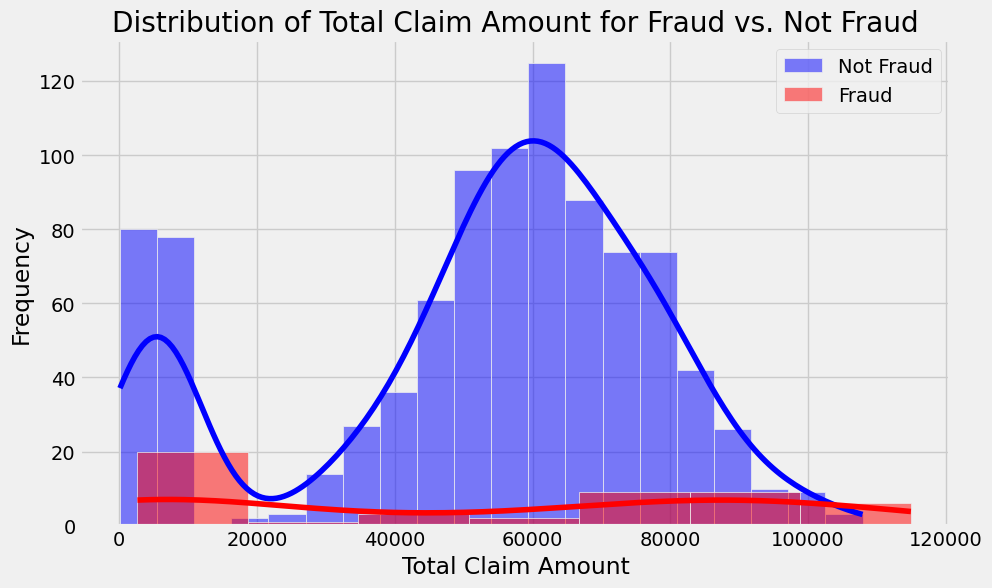


Comparison of fraud vs. non-fraud feature means:
                        Feature   Fraud Mean  Non-Fraud Mean    Difference
5                umbrella_limit  3820000.000   957894.736842  2.862105e+06
6                   insured_zip   526946.060   499860.194737  2.708587e+04
7                 capital-gains    32586.000    24733.473684  7.852526e+03
2                 policy_number   542588.400   546430.766316  3.842366e+03
16                vehicle_claim    35417.000    38061.157895  2.644158e+03
13           total_claim_amount    51230.200    52842.557895  1.612358e+03
15               property_claim     8249.400     7354.842105  8.945579e+02
8                  capital-loss   -27386.000   -26762.526316  6.234737e+02
3             policy_deductable     1480.000     1117.894737  3.621053e+02
14                 injury_claim     7563.800     7426.557895  1.372421e+02
0            months_as_customer      225.760      202.806316  2.295368e+01
4         policy_annual_premium     1234.656     1

In [106]:
# Import necessary libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Visualize the distribution of one of the numerical features for fraud vs. non-fraud
# For example, 'total_claim_amount' (or any numerical column in your dataset)
plt.figure(figsize=(10, 6))

# Plot distribution of a specific feature (replace 'total_claim_amount' with a feature from your dataset)
sns.histplot(df[df['fraud_prediction'] == 'Not Fraud']['total_claim_amount'], color='blue', label='Not Fraud', kde=True)
sns.histplot(df[df['fraud_prediction'] == 'Fraud']['total_claim_amount'], color='red', label='Fraud', kde=True)

plt.title('Distribution of Total Claim Amount for Fraud vs. Not Fraud')
plt.xlabel('Total Claim Amount')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Step 2: Check the statistics of fraud vs. non-fraud cases for all numerical features

# Add the new features created from date columns to the original DataFrame (df)
df['policy_bind_year'] = features['policy_bind_year']
df['policy_bind_month'] = features['policy_bind_month']
df['policy_bind_day'] = features['policy_bind_day']
df['incident_year'] = features['incident_year']
df['incident_month'] = features['incident_month']
df['incident_day'] = features['incident_day']

# Select only numerical features for calculating the mean
numerical_features = df.select_dtypes(include=np.number)

fraud_stats = numerical_features[df['fraud_prediction'] == 'Fraud'].mean() # Calculate the mean for numerical columns for fraud cases
non_fraud_stats = numerical_features[df['fraud_prediction'] == 'Not Fraud'].mean() # Calculate the mean for numerical columns for non-fraud cases

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Feature': fraud_stats.index,
    'Fraud Mean': fraud_stats.values,
    'Non-Fraud Mean': non_fraud_stats.values
})

# Sort by the most significant difference
comparison_df['Difference'] = abs(comparison_df['Fraud Mean'] - comparison_df['Non-Fraud Mean'])
comparison_df = comparison_df.sort_values(by='Difference', ascending=False)

# Print the comparison table
print("\nComparison of fraud vs. non-fraud feature means:")
print(comparison_df)

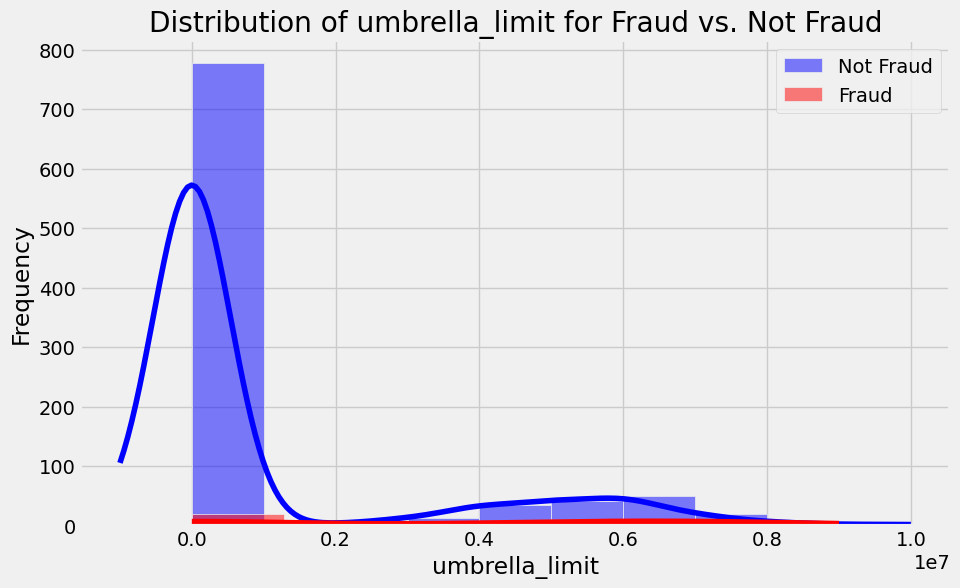

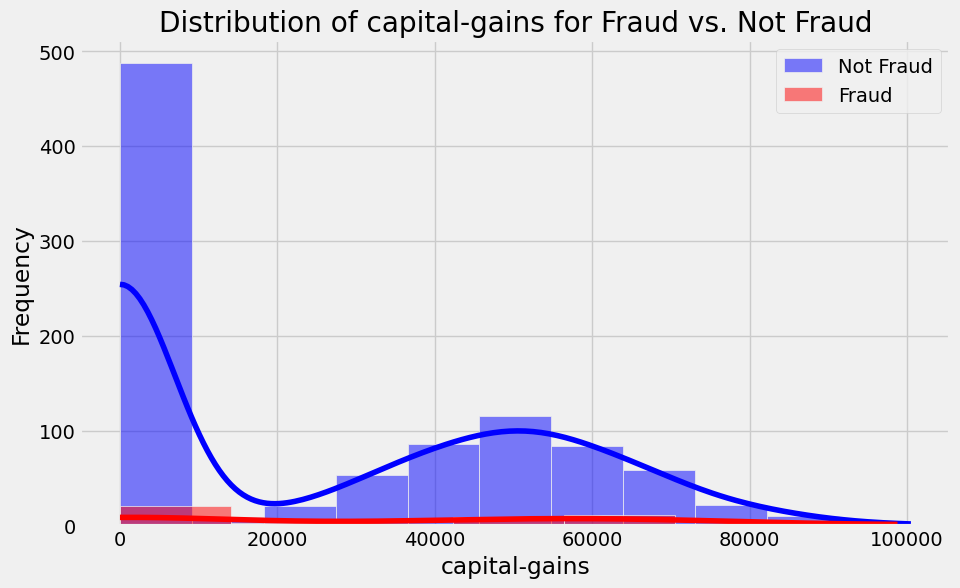

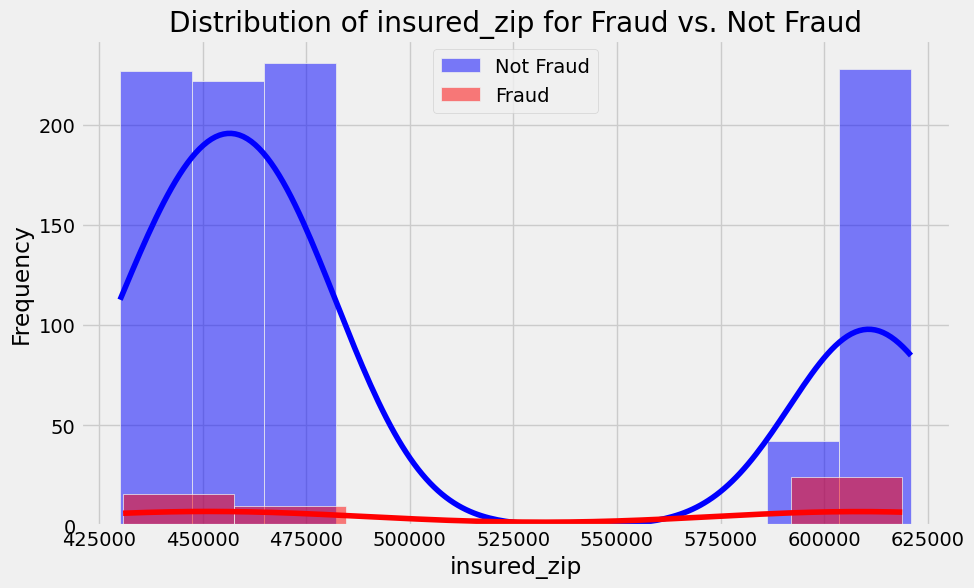

In [107]:
# Visualizing the distribution of top features for fraud vs. non-fraud
top_features = ['umbrella_limit', 'capital-gains', 'insured_zip']  # Modify based on your dataset

for feature in top_features:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[df['fraud_prediction'] == 'Not Fraud'][feature], color='blue', label='Not Fraud', kde=True)
    sns.histplot(df[df['fraud_prediction'] == 'Fraud'][feature], color='red', label='Fraud', kde=True)

    plt.title(f'Distribution of {feature} for Fraud vs. Not Fraud')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()


PCA

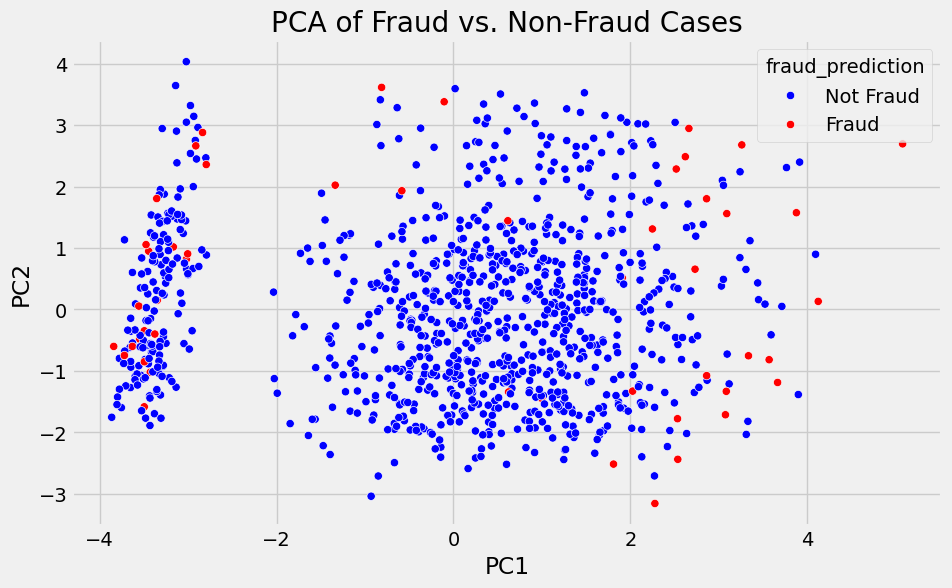

In [108]:
from sklearn.decomposition import PCA
import seaborn as sns

# Perform PCA to reduce the dimensionality to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a new DataFrame for visualization
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['fraud_prediction'] = df['fraud_prediction']

# Plot the PCA results
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='fraud_prediction', palette=['blue', 'red'])
plt.title('PCA of Fraud vs. Non-Fraud Cases')
plt.show()


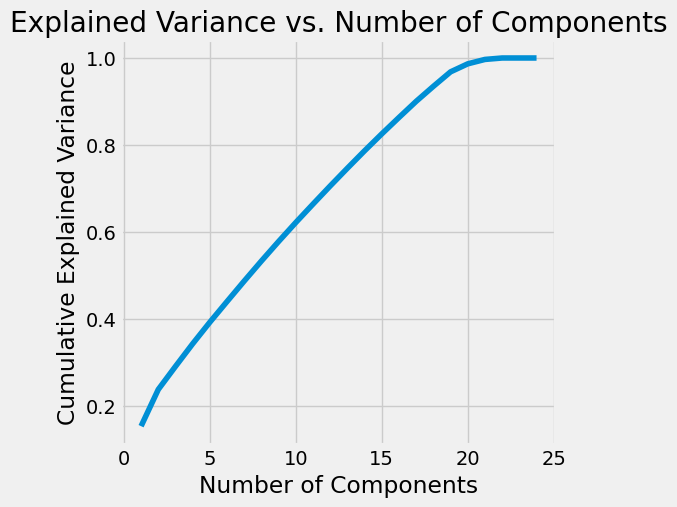

In [109]:
pca = PCA().fit(X_scaled)
explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.plot(range(1, len(explained_variance) + 1), explained_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.show()


SMOTE

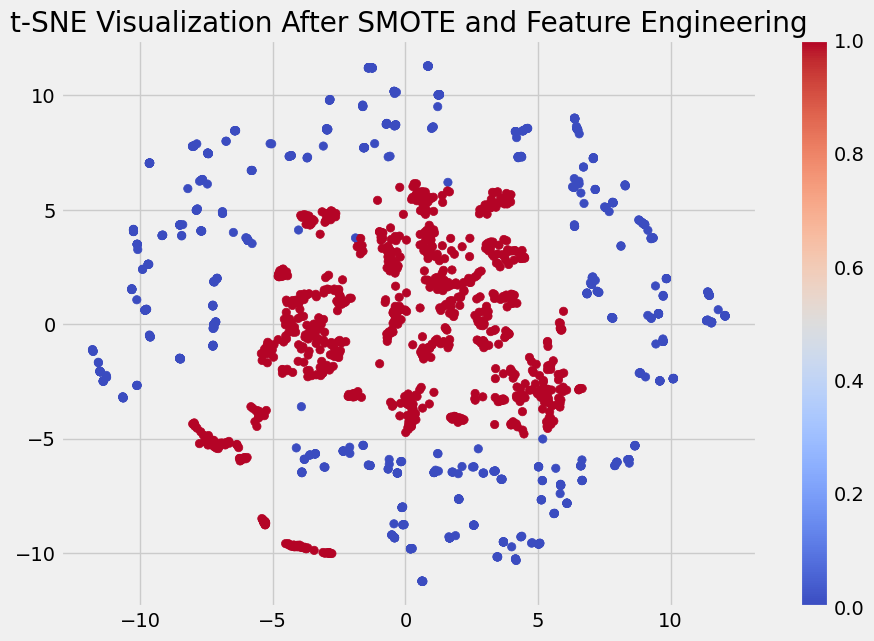

In [110]:
# Import necessary libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your DataFrame and 'fraud_prediction' is your target variable
# Separate features (X) and target (y)
X = df.drop('fraud_prediction', axis=1)  # Features
y = df['fraud_prediction']  # Target variable

# Encode the target variable
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# Step 1: Apply SMOTE to balance the data
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import pandas as pd
import matplotlib.pyplot as plt

# Convert date columns to datetime objects
for col in X.columns:
    if X[col].dtype == 'object':  # Check if column is of object type
        try:
            X[col] = pd.to_datetime(X[col])
        except:
            pass

# Extract numerical features from datetime columns
X['policy_bind_year'] = X['policy_bind_date'].dt.year
X['policy_bind_month'] = X['policy_bind_date'].dt.month
X['policy_bind_day'] = X['policy_bind_date'].dt.day
X['incident_year'] = X['incident_date'].dt.year
X['incident_month'] = X['incident_date'].dt.month
X['incident_day'] = X['incident_date'].dt.day

# Drop the original date columns
X = X.drop(['policy_bind_date', 'incident_date'], axis=1)

# Identify non-numeric columns
non_numeric_cols = X.select_dtypes(exclude=['number']).columns

# One-hot encode non-numeric columns
X = pd.get_dummies(X, columns=non_numeric_cols)

# 1. Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# 2. Feature Engineering: Scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

# 3. Optional: Dimensionality Reduction with PCA (prior to t-SNE for performance)
# Reducing to, let's say, 30 components for better performance with t-SNE.
pca = PCA(n_components=30)
X_pca = pca.fit_transform(X_scaled)

# Step 3: Run t-SNE on the improved dataset
tsne = TSNE(n_components=2, random_state=42, n_iter=300, perplexity=30)
X_tsne = tsne.fit_transform(X_pca)

# Step 4: Visualize the t-SNE results
plt.figure(figsize=(10, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_resampled, cmap='coolwarm', label=y_resampled)
plt.title('t-SNE Visualization After SMOTE and Feature Engineering')
plt.colorbar()
plt.show()

K MEANS

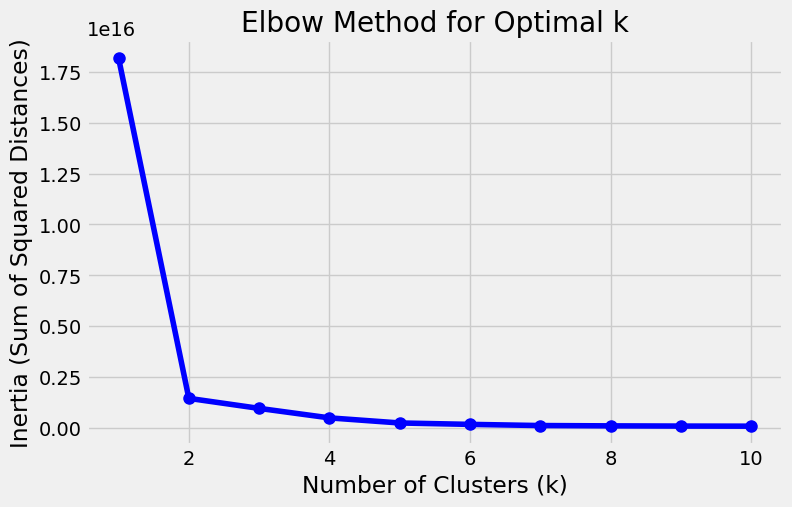

In [111]:
# Import necessary libraries
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Step 1: Use the Elbow Method to find the optimal number of clusters (k)
inertia = []
k_values = range(1, 11)  # Try different values of k from 1 to 10

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_resampled)  # X_resampled is your data after SMOTE and feature engineering
    inertia.append(kmeans.inertia_)

# Step 2: Plot the Elbow Method result to find the optimal k
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()




Silhouette Score: 0.8572
Adjusted Rand Index (ARI): 0.1655
Adjusted Mutual Information (AMI): 0.1375


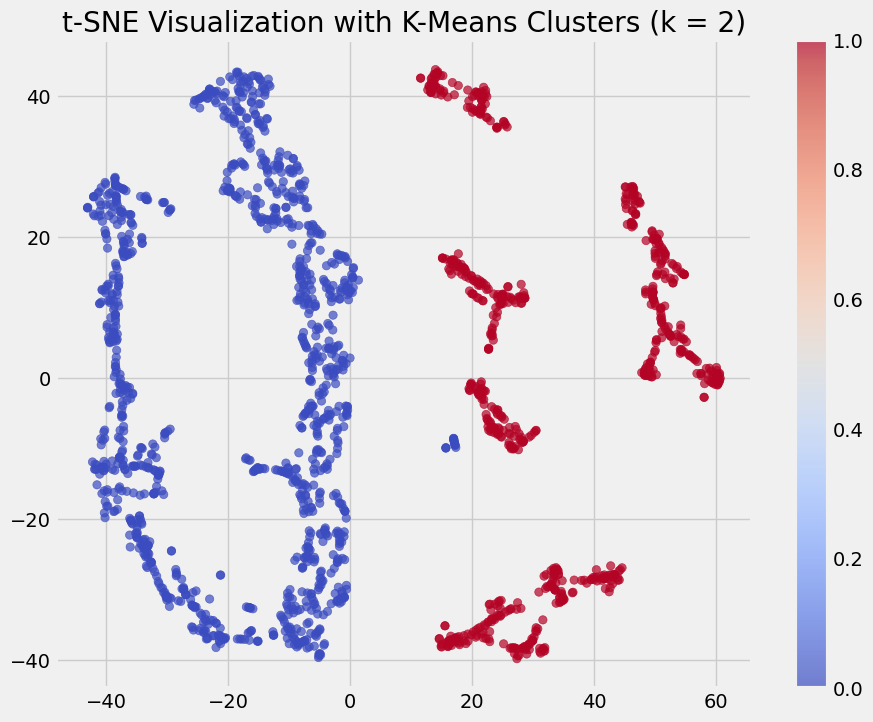


Classification Metrics (based on clustering):
Accuracy: 0.7037
Precision: 0.6611
Recall: 0.8358
F1 Score: 0.7383
Confusion Matrix:
[[543 407]
 [156 794]]


In [113]:
from sklearn.metrics import silhouette_score, adjusted_rand_score, adjusted_mutual_info_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# Step 1: Apply K-Means Clustering (after determining optimal k from Elbow method)
optimal_k = 2  # You can set this to the value from the Elbow method
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(X_resampled)  # X_resampled has 1900 samples after resampling

# Step 2: Calculate Clustering Evaluation Metrics
# Silhouette Score (measures how similar points are within clusters)
silhouette_avg = silhouette_score(X_resampled, clusters)
print(f'Silhouette Score: {silhouette_avg:.4f}')

# Adjusted Rand Index (ARI) and Adjusted Mutual Information (AMI)
# Using the resampled true labels
ari = adjusted_rand_score(y_resampled, clusters)
ami = adjusted_mutual_info_score(y_resampled, clusters)
print(f'Adjusted Rand Index (ARI): {ari:.4f}')
print(f'Adjusted Mutual Information (AMI): {ami:.4f}')

# Step 3: Visualize the clusters using t-SNE for dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_resampled)

plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, cmap='coolwarm', alpha=0.7)
plt.title(f't-SNE Visualization with K-Means Clusters (k = {optimal_k})')
plt.colorbar()
plt.show()

# Step 4: Calculate Classification Metrics (based on clustering and true labels)
# Mapping clusters to the majority labels (fraud or not-fraud)
# y_resampled: 1 for Fraud, 0 for Not Fraud (resampled labels)
predicted_labels = clusters

if len(set(predicted_labels)) == 2:  # Check if we have two clusters
    majority_class_map = {
        0: np.argmax(np.bincount(y_resampled[predicted_labels == 0])),  # Cluster 0 majority
        1: np.argmax(np.bincount(y_resampled[predicted_labels == 1]))   # Cluster 1 majority
    }
    predicted_labels = np.array([majority_class_map[cluster] for cluster in predicted_labels])

# Step 5: Calculate evaluation metrics
accuracy = accuracy_score(y_resampled, predicted_labels)
precision = precision_score(y_resampled, predicted_labels)
recall = recall_score(y_resampled, predicted_labels)
f1 = f1_score(y_resampled, predicted_labels)
cm = confusion_matrix(y_resampled, predicted_labels)

print(f"\nClassification Metrics (based on clustering):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Confusion Matrix:\n{cm}")


GMM- GAUSSIAN MIXTURE MODEL

In [115]:
from sklearn.mixture import GaussianMixture
for n_clusters in range(2, 10):
    gmm = GaussianMixture(n_components=n_clusters, random_state=42)
    gmm_labels = gmm.fit_predict(X_scaled)
    silhouette = silhouette_score(X_scaled, gmm_labels)
    print(f"n_clusters: {n_clusters}, Silhouette Score: {silhouette}")


n_clusters: 2, Silhouette Score: 0.18632927950196318
n_clusters: 3, Silhouette Score: 0.18426148441383783
n_clusters: 4, Silhouette Score: -0.017340357785476466
n_clusters: 5, Silhouette Score: -0.14110484224179978
n_clusters: 6, Silhouette Score: -0.14096766572941155
n_clusters: 7, Silhouette Score: -0.13065004210412784
n_clusters: 8, Silhouette Score: -0.14069851096888816
n_clusters: 9, Silhouette Score: -0.1405619542870084


HDBSCAN

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 33.2 MB/s eta 0:00:00
Silhouette Score: 0.7978
Adjusted Rand Index (ARI): 0.1010
Adjusted Mutual Information (AMI): 0.1106


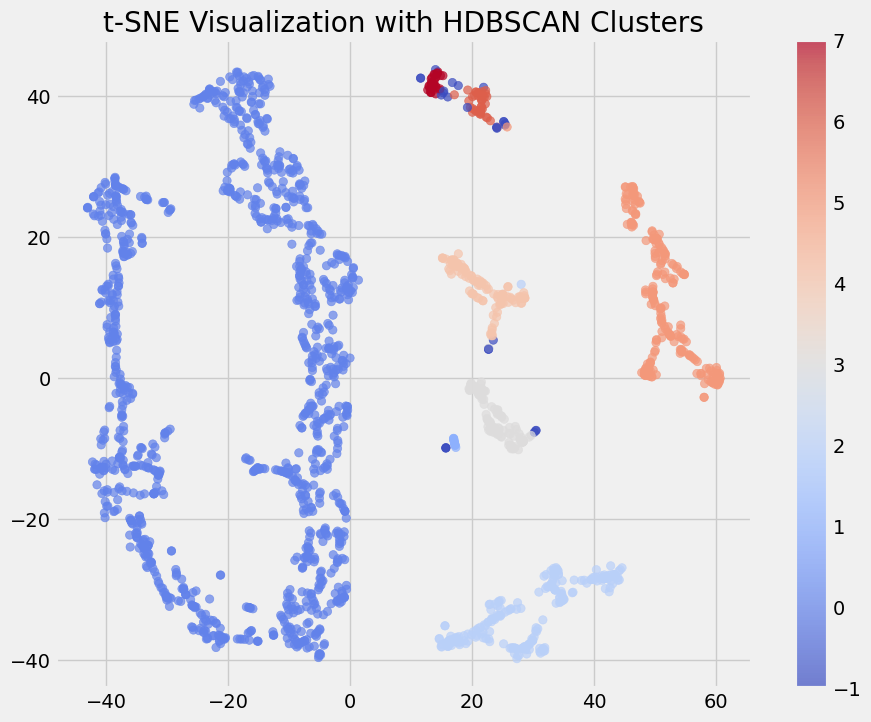


Classification Metrics (based on clustering):
Accuracy: 0.7021
Precision: 0.6603
Recall: 0.8326
F1 Score: 0.7365
Confusion Matrix:
[[543 407]
 [159 791]]


In [116]:

!pip install hdbscan
import hdbscan

# Assuming X_resampled is your data after SMOTE and feature engineering
# Step 1: Apply HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=10, gen_min_span_tree=True)  # You may need to adjust min_cluster_size
clusters = clusterer.fit_predict(X_resampled)

# Step 2: Calculate Clustering Evaluation Metrics
# Silhouette Score (measures how similar points are within clusters)
silhouette_avg = silhouette_score(X_resampled, clusters)
print(f'Silhouette Score: {silhouette_avg:.4f}')

# Adjusted Rand Index (ARI) and Adjusted Mutual Information (AMI)
# Using the resampled true labels
ari = adjusted_rand_score(y_resampled, clusters)
ami = adjusted_mutual_info_score(y_resampled, clusters)
print(f'Adjusted Rand Index (ARI): {ari:.4f}')
print(f'Adjusted Mutual Information (AMI): {ami:.4f}')

# Step 3: Visualize the clusters using t-SNE for dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_resampled)

plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, cmap='coolwarm', alpha=0.7)
plt.title('t-SNE Visualization with HDBSCAN Clusters')
plt.colorbar()
plt.show()

# Step 4: Calculate Classification Metrics (based on clustering and true labels)
# Mapping clusters to the majority labels (fraud or not-fraud)
# y_resampled: 1 for Fraud, 0 for Not Fraud (resampled labels)
predicted_labels = clusters

# Find the majority label for each cluster
unique_clusters = np.unique(clusters)
majority_class_map = {}
for cluster in unique_clusters:
    if cluster != -1:  # Ignore noise points
        majority_class_map[cluster] = np.argmax(np.bincount(y_resampled[clusters == cluster]))

# Assign majority label to the predicted clusters (excluding noise)
predicted_labels_majority = np.array([majority_class_map.get(cluster, -1) for cluster in predicted_labels])

# Replace noise points (-1) with a predefined label or ignore them for evaluation
predicted_labels_majority[predicted_labels_majority == -1] = 0  # Replace noise with 0 (or any suitable value)

# Step 5: Calculate evaluation metrics
accuracy = accuracy_score(y_resampled, predicted_labels_majority)
precision = precision_score(y_resampled, predicted_labels_majority)
recall = recall_score(y_resampled, predicted_labels_majority)
f1 = f1_score(y_resampled, predicted_labels_majority)
cm = confusion_matrix(y_resampled, predicted_labels_majority)

print(f"\nClassification Metrics (based on clustering):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Confusion Matrix:\n{cm}")

#autoencoder

Advanced autoencoder

In [150]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Assuming X_resampled and y_resampled are your data after SMOTE and feature engineering

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Enhanced Autoencoder Model
input_dim = X_train_scaled.shape[1]
encoding_dim = 64  # Increased encoding dimension for better representation

# Autoencoder architecture with additional layers
input_layer = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_layer)
encoded = BatchNormalization()(encoded)
encoded = Dense(encoding_dim, activation='relu')(encoded)
encoded = Dropout(0.3)(encoded)  # Dropout layer to prevent overfitting
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Train the enhanced autoencoder
autoencoder.fit(X_train_scaled, X_train_scaled, epochs=35, batch_size=64, shuffle=True, validation_split=0.1)

# Extract the encoder part of the autoencoder
encoder = Model(input_layer, encoded)

# Get the encoded representation of the training and testing data
X_train_encoded = encoder.predict(X_train_scaled)
X_test_encoded = encoder.predict(X_test_scaled)

# Neural Network Model
mlp = MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation='relu', solver='adam', max_iter=500, random_state=42)

# Train the neural network using the encoded data
mlp.fit(X_train_encoded, y_train)

# Make predictions on the testing data
y_pred = mlp.predict(X_test_encoded)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"\nClassification Metrics (Enhanced Autoencoder + Neural Network):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Confusion Matrix:\n{cm}")


Epoch 1/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 1.0248 - val_loss: 0.8868
Epoch 2/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8337 - val_loss: 0.8444
Epoch 3/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8517 - val_loss: 0.8433
Epoch 4/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.8162 - val_loss: 0.8425
Epoch 5/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8325 - val_loss: 0.8413
Epoch 6/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.8364 - val_loss: 0.8393
Epoch 7/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8453 - val_loss: 0.8364
Epoch 8/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.8287 - val_loss: 0.8325
Epoch 9/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8117 - val_loss: 0.8295
Epoch 10/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.8190 - val_loss: 0.8267
Epoch 11/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.8188 - val_loss: 0.8247
Epoch 12/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.8

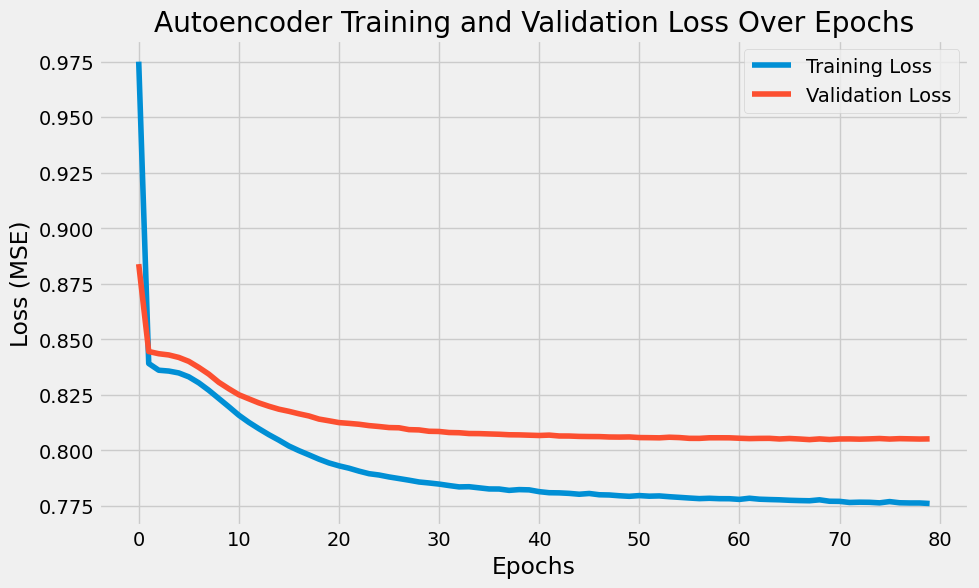

In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# Assuming you've already trained your models and evaluated the metrics

# 1. Plot Autoencoder Loss Curve (Training vs Validation Loss)
history = autoencoder.history  # Assuming this is the returned History object from `autoencoder.fit`

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


<Figure size 800x600 with 0 Axes>

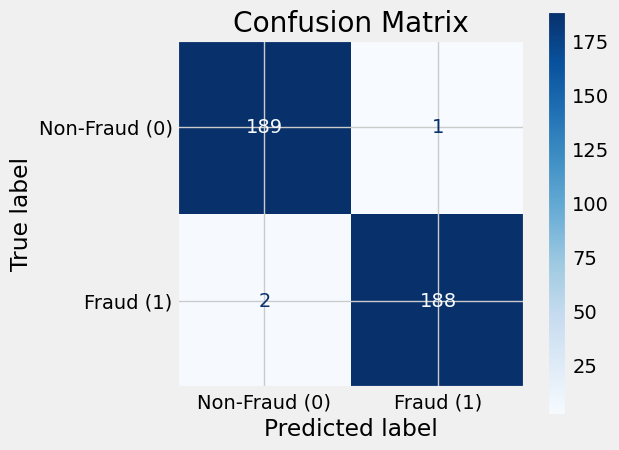

In [135]:

# 2. Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Fraud (0)', 'Fraud (1)']).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()



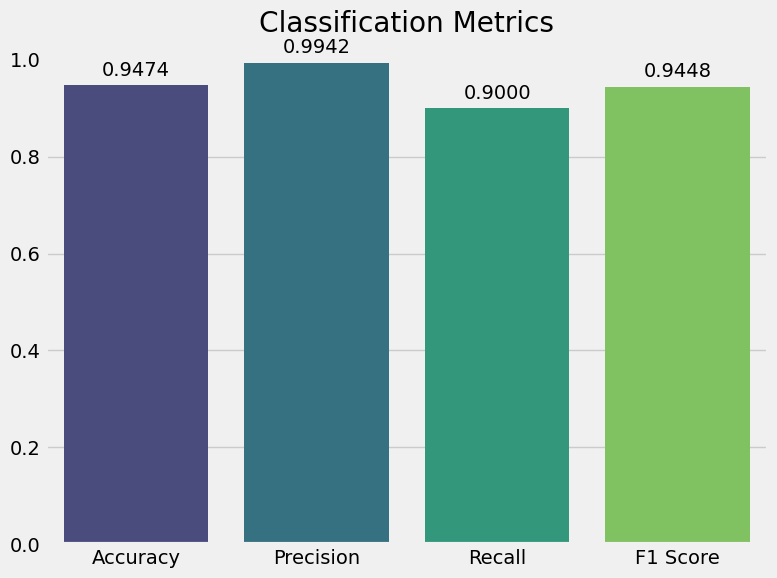

In [147]:
# 3. Bar Plot for Classification Metrics (Accuracy, Precision, Recall, F1 Score)
metrics = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1 Score': f1}

plt.figure(figsize=(8, 6))
sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='viridis')
plt.title('Classification Metrics', pad=20)  # Adding padding to the title
plt.ylim(0, 1)  # Since metrics are between 0 and 1
for i, value in enumerate(metrics.values()):
    plt.text(i, value + 0.02, f'{value:.4f}', ha='center')

plt.tight_layout()  # Adjust the layout to prevent overlaps
plt.show()


#monte carlo

In [124]:
# Rerunning the simulation and displaying the results without ace_tools

# Re-import necessary libraries and prepare the simulation
import numpy as np
import pandas as pd

# Load the dataset again
file_path = '/content/Dataset.csv'
data = pd.read_csv(file_path)

# Clean and preprocess the data (remove missing or irrelevant features for simplicity)
data_cleaned = data[['total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'police_report_available', 'fraud_reported']]
data_cleaned['police_report_available'] = data_cleaned['police_report_available'].apply(lambda x: 1 if x == 'YES' else 0)
data_cleaned['fraud_reported'] = data_cleaned['fraud_reported'].apply(lambda x: 1 if x == 'Y' else 0)

# Separate features and target
X = data_cleaned[['total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'police_report_available']]

# Monte Carlo Simulation function
def monte_carlo_simulation(X, n_simulations=1000):
    np.random.seed(42)  # For reproducibility
    fraud_probabilities = []

    for i in range(n_simulations):
        # Randomly sample from the dataset
        sample = X.sample(n=len(X), replace=True)

        # Assume some variables influence fraud probability
        total_claim = sample['total_claim_amount'].mean()
        injury_claim = sample['injury_claim'].mean()
        property_claim = sample['property_claim'].mean()
        vehicle_claim = sample['vehicle_claim'].mean()
        police_report = sample['police_report_available'].mean()

        # Simple heuristic to calculate fraud probability
        fraud_probability = (total_claim * 0.00001 + injury_claim * 0.0001 + property_claim * 0.0001 +
                             vehicle_claim * 0.00005 - police_report * 0.1)
        fraud_probabilities.append(fraud_probability)

    return fraud_probabilities

# Run Monte Carlo simulation
n_simulations = 1000
fraud_simulations = monte_carlo_simulation(X, n_simulations)

# Analyze results
fraud_simulation_results = pd.DataFrame(fraud_simulations, columns=['Simulated Fraud Probability'])
fraud_simulation_results['Fraud Likelihood'] = fraud_simulation_results['Simulated Fraud Probability'].apply(lambda x: 'High' if x > 0.5 else 'Low')

# Display the simulation results
fraud_simulation_results.head()


,Simulated Fraud Probability,Fraud Likelihood
0,3.875975,High
1,3.934949,High
2,3.867304,High
3,3.909470,High
4,3.808302,High


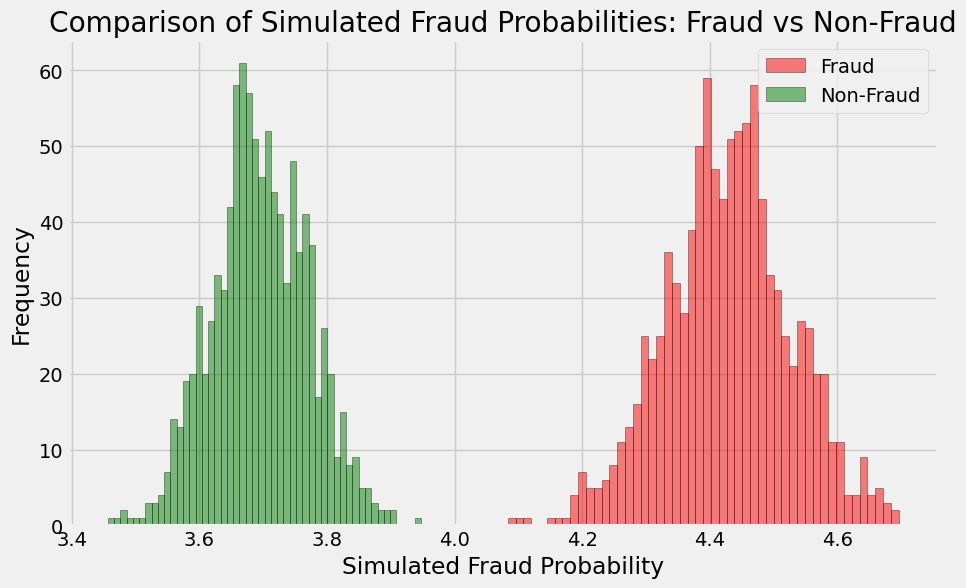

In [125]:
# Grouping the dataset into fraud and non-fraud based on the actual 'fraud_reported' column
fraud_cases = data_cleaned[data_cleaned['fraud_reported'] == 1]
non_fraud_cases = data_cleaned[data_cleaned['fraud_reported'] == 0]

# Monte Carlo Simulation function remains the same, so let's simulate fraud probabilities for both groups

# Run Monte Carlo simulation for fraud cases
fraud_simulations = monte_carlo_simulation(fraud_cases[['total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'police_report_available']])

# Run Monte Carlo simulation for non-fraud cases
non_fraud_simulations = monte_carlo_simulation(non_fraud_cases[['total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'police_report_available']])

# Convert results to DataFrames
fraud_simulation_results = pd.DataFrame(fraud_simulations, columns=['Simulated Fraud Probability'])
non_fraud_simulation_results = pd.DataFrame(non_fraud_simulations, columns=['Simulated Fraud Probability'])

# Visualize the comparison
plt.figure(figsize=(10,6))

# Plot fraud cases
plt.hist(fraud_simulation_results['Simulated Fraud Probability'], bins=50, alpha=0.5, label='Fraud', color='red', edgecolor='black')

# Plot non-fraud cases
plt.hist(non_fraud_simulation_results['Simulated Fraud Probability'], bins=50, alpha=0.5, label='Non-Fraud', color='green', edgecolor='black')

plt.title('Comparison of Simulated Fraud Probabilities: Fraud vs Non-Fraud')
plt.xlabel('Simulated Fraud Probability')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()
